# Comparação de Estratégias YAFS: Latência vs Custom vs Round-Robin
*YAFS Strategy Comparison: Latency vs Custom vs Round-Robin*

Este notebook compara resultados de simulação entre três estratégias de posicionamento/seleção:
- **Latência** – seleciona o caminho de menor latência
- **Custom** – estratégia de alocação personalizada
- **Round-Robin** – distribui requisições uniformemente entre os nós disponíveis

*This notebook compares simulation results across three placement/selection strategies.*

Comparamos / *We compare*:
1. Distribuições gerais de latência / *Overall latency distributions*
2. Tempo de serviço e tempo de rede/espera / *Service time & network/wait time*
3. Distribuição de carga por nó / *Per-node workload distribution*
4. Tráfego acumulado e latência ao longo do tempo / *Cumulative traffic & latency over time*
5. Análise de falhas / *Failure analysis*
6. Contagem de nós ao longo do tempo / *Node counts over time*

> **🌐 Idioma / Language:** Altere `LANG = "pt"` para `LANG = "en"` na célula de configuração abaixo e re-execute o notebook para alternar entre Português e Inglês.
> *Change `LANG = "pt"` to `LANG = "en"` in the configuration cell below and re-run the notebook to switch between Portuguese and English.*

In [109]:
# Install analysis dependencies (idempotent)
%pip install -q pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [111]:
# ============================================================
# 🌐 Language Configuration / Configuração de Idioma
# Change LANG to "en" for English or "pt" for Portuguese (Brasil)
# Altere LANG para "en" (Inglês) ou "pt" (Português Brasil)
# ============================================================
LANG = "pt"

# ============================================================
# 🏷️ Strategy Display Names / Nomes de Exibição das Estratégias
# Change these to customize how strategies appear in plots/tables
# Altere para personalizar como as estratégias aparecem nos gráficos/tabelas
# ============================================================
STRATEGY_NAMES = {
    "latency": "Dijkstra",
    "custom": "RAFFA",
    "roundrobin": "Round-Robin",
}

def S(key):
    """Get display name for a strategy. / Obtém o nome de exibição da estratégia."""
    return STRATEGY_NAMES.get(key, key)

# Colour palette for strategies (keyed by display name, consistent across all plots)
# Balanced tones: formal yet clearly distinguishable
STRATEGY_PALETTE = {S("latency"): "#2C81C7", S("custom"): "#4BA84E", S("roundrobin"): "#DB8E1C"}

_TRANSLATIONS = {
    # === General labels ===
    "strategy": {"pt": "Estratégia", "en": "Strategy"},
    "latency_ms": {"pt": "Latência (ms)", "en": "Latency (ms)"},
    "time_ms": {"pt": "Tempo (ms)", "en": "Time (ms)"},
    "simulation_time": {"pt": "Tempo de Simulação", "en": "Simulation Time"},
    "message_count": {"pt": "Quantidade de Mensagens", "en": "Message Count"},
    "component": {"pt": "Componente", "en": "Component"},
    "count": {"pt": "Contagem", "en": "Count"},
    "outcome": {"pt": "Resultado", "en": "Outcome"},
    "node_type_label": {"pt": "Tipo de Nó", "en": "Node Type"},
    "processing_location": {"pt": "Local de Processamento", "en": "Processing Location"},
    "hops": {"pt": "Saltos", "en": "Hops"},
    "failures": {"pt": "Falhas", "en": "Failures"},

    # === Section 1 – Quick summary column names ===
    "col_messages": {"pt": "Mensagens", "en": "Messages"},
    "col_mean": {"pt": "Média (ms)", "en": "Mean (ms)"},
    "col_median": {"pt": "Mediana (ms)", "en": "Median (ms)"},
    "col_std": {"pt": "Desvio Padrão (ms)", "en": "Std (ms)"},
    "col_min": {"pt": "Mín (ms)", "en": "Min (ms)"},
    "col_max": {"pt": "Máx (ms)", "en": "Max (ms)"},

    # === Section 2 – Latency Distribution ===
    "title_lat_box": {"pt": "Distribuição de Latência (Boxplot)", "en": "Latency Distribution (Box)"},
    "title_lat_violin": {"pt": "Distribuição de Latência (Violino)", "en": "Latency Distribution (Violin)"},
    "title_lat_kde": {"pt": "KDE de Latência", "en": "Latency KDE"},

    # === Section 3 – Breakdown ===
    "title_breakdown": {"pt": "Latência Média por Estratégia",
                         "en": "Mean Latency per Strategy"},

    # === Section 4 – Latency Over Time ===
    "title_lat_over_time": {"pt": "Latência ao Longo do Tempo de Simulação", "en": "Latency Over Simulation Time"},
    "title_rolling_lat": {"pt": "Média Móvel de Latência (janela=50)", "en": "Rolling Average Latency (window=50)"},

    # === Section 5 – Workload ===
    "title_msgs_per_node": {"pt": "Mensagens Processadas por Nó (Top 20 – apenas M_Req)",
                             "en": "Messages Processed per Node (Top 20 – M_Req only)"},
    "xlabel_dst_node": {"pt": "Nó de Destino", "en": "Destination Node"},

    # === Section 6 – Latency by Msg Type ===
    "title_lat_msg_type": {"pt": "Latência por Estratégia",
                            "en": "Latency by Strategy"},

    # === Section 7 – Cumulative ===
    "title_cum_msgs": {"pt": "Mensagens Acumuladas ao Longo do Tempo", "en": "Cumulative Messages Over Time"},
    "ylabel_total_msgs": {"pt": "Total de Mensagens", "en": "Total Messages"},
    "title_cum_lat": {"pt": "Latência Acumulada ao Longo do Tempo", "en": "Cumulative Latency Over Time"},
    "ylabel_total_lat": {"pt": "Latência Total (ms)", "en": "Total Latency (ms)"},

    # === Section 8 – Heatmaps ===
    "title_heatmap": {"pt": "Mapa de Calor de Comunicação – {strat}",
                       "en": "Communication Heatmap – {strat}"},
    "no_comm_data": {"pt": "Sem dados de comunicação", "en": "No communication data"},
    "no_data_suffix": {"pt": "\n(sem dados)", "en": "\n(no data)"},

    # === Section 9 – Failures ===
    "title_fail_over_time": {"pt": "Falhas Acumuladas ao Longo do Tempo por Estratégia",
                              "en": "Cumulative Failures Over Time by Strategy"},
    "title_fail_reasons": {"pt": "Motivos de Falha por Estratégia", "en": "Failure Reasons by Strategy"},
    "title_total_failures": {"pt": "Total de Falhas por Estratégia", "en": "Total Failures per Strategy"},
    "no_failure_data": {"pt": "Nenhum dado de falha encontrado.", "en": "No failure data found for any strategy."},

    # === Section 10 – Node Counts ===
    "title_total_nodes": {"pt": "Total de Nós Ativos ao Longo do Tempo",
                           "en": "Total Active Nodes Over Time"},
    "ylabel_total_nodes": {"pt": "Total de Nós", "en": "Total Nodes"},
    "title_node_roles": {"pt": "Funções dos Nós – {strat}", "en": "Node Roles – {strat}"},
    "no_node_count": {"pt": "Nenhum dado de contagem de nós encontrado.", "en": "No node-count data found."},

    # === Section 11 – Summary Table ===
    "col_total_msgs": {"pt": "Total de Mensagens", "en": "Total Messages"},
    "col_mean_lat": {"pt": "Latência Média (ms)", "en": "Mean Latency (ms)"},
    "col_median_lat": {"pt": "Latência Mediana (ms)", "en": "Median Latency (ms)"},
    "col_p95_lat": {"pt": "Latência P95 (ms)", "en": "P95 Latency (ms)"},
    "col_p99_lat": {"pt": "Latência P99 (ms)", "en": "P99 Latency (ms)"},
    "col_std_lat": {"pt": "Desvio Padrão (ms)", "en": "Std Latency (ms)"},
    "col_mean_svc": {"pt": "Tempo Médio de Serviço (ms)", "en": "Mean Service Time (ms)"},
    "col_mean_net": {"pt": "Tempo Médio de Rede (ms)", "en": "Mean Network Time (ms)"},
    "col_failures": {"pt": "Falhas", "en": "Failures"},

    # === Section 13 – Decomposition ===
    "col_network": {"pt": "Rede (ms)", "en": "Network (ms)"},
    "col_queue_wait": {"pt": "Espera na Fila (ms)", "en": "Queue Wait (ms)"},
    "col_processing": {"pt": "Processamento (ms)", "en": "Processing (ms)"},
    "col_total": {"pt": "Total (ms)", "en": "Total (ms)"},
    "title_decomp": {"pt": "Decomposição Média da Latência por Estratégia",
                      "en": "Mean Latency Decomposition per Strategy"},
    "title_net_lat_dist": {"pt": "Distribuição da Latência de Rede por Estratégia",
                            "en": "Network Latency Distribution by Strategy"},
    "title_queue_dist": {"pt": "Distribuição do Tempo de Espera na Fila por Estratégia",
                          "en": "Queue Wait Time Distribution by Strategy"},
    "title_proc_dist": {"pt": "Distribuição do Tempo de Processamento por Estratégia",
                         "en": "Processing Time Distribution by Strategy"},

    # === Section 14 – Link Metrics ===
    "title_buffer_over_time": {"pt": "Buffer Médio da Rede (Mensagens em Trânsito) ao Longo do Tempo",
                                "en": "Average Network Buffer (In-Flight Messages) Over Time"},
    "ylabel_avg_buffer": {"pt": "Tamanho Médio do Buffer", "en": "Avg Buffer Size"},
    "title_link_queue_delay": {"pt": "Atraso Médio de Fila nos Links ao Longo do Tempo",
                                "en": "Average Link Queuing Delay Over Time"},
    "ylabel_wait_per_hop": {"pt": "Tempo de Espera (por salto)", "en": "Wait Time (per hop)"},
    "title_hops_per_msg": {"pt": "Número de Saltos por Mensagem", "en": "Number of Hops per Message"},
    "no_link_data": {"pt": "Nenhum dado de link disponível.", "en": "No link data available."},

    # === Section 15 – Reliability ===
    "col_successful": {"pt": "Entregues", "en": "Successful"},
    "col_failed": {"pt": "Com Falha", "en": "Failed"},
    "col_total_generated": {"pt": "Total Gerado", "en": "Total Generated"},
    "col_delivery_rate": {"pt": "Taxa de Entrega (%)", "en": "Delivery Rate (%)"},
    "title_delivery_rate": {"pt": "Mensagens Transmitidas com Sucesso", "en": "Percentage of Successfully Sent Messages"},
    "ylabel_delivery_rate": {"pt": "Taxa de Sucesso (%)", "en": "Successful Messages (%)"},
    "title_success_fail": {"pt": "Mensagens Entregues vs Com Falha", "en": "Successful vs Failed Messages"},

    # === Section 16 – Throughput ===
    "title_throughput": {"pt": "Vazão ao Longo do Tempo (bin = {bin} unidades de tempo)",
                          "en": "Throughput Over Time (bin = {bin} time units)"},
    "title_smooth_throughput": {"pt": "Vazão Suavizada (média móvel, janela=5 bins)",
                                 "en": "Smoothed Throughput (rolling avg, window=5 bins)"},
    "ylabel_msgs_window": {"pt": "Mensagens / Janela", "en": "Messages / Window"},

    # === Section 17 – Cloud Offload ===
    "title_cloud_fog": {"pt": "Distribuição de Processamento Cloud vs Fog (M_Req)",
                         "en": "Cloud vs Fog Processing Distribution (M_Req)"},

    # === Section 18 – Gini ===
    "title_gini": {"pt": "Balanceamento de Carga: Coef. de Gini (menor = mais balanceado)",
                    "en": "Load Balance: Gini Coefficient (lower = more balanced)"},
    "ylabel_gini": {"pt": "Coeficiente de Gini", "en": "Gini Coefficient"},
    "title_svc_per_node": {"pt": "Tempo Total de Serviço por Nó – {strat}",
                            "en": "Total Service Time per Node – {strat}"},
    "ylabel_total_svc": {"pt": "Tempo Total de Serviço (ms)", "en": "Total Service Time (ms)"},
    "no_data": {"pt": "Sem dados", "en": "No data"},

    # === Section 19 – Energy ===
    "title_total_energy": {"pt": "Consumo Total Estimado de Energia",
                            "en": "Total Estimated Energy Consumption"},
    "ylabel_energy_j": {"pt": "Energia (Joules)", "en": "Energy (Joules)"},
    "title_energy_per_msg": {"pt": "Energia por Mensagem", "en": "Energy per Message"},
    "title_energy_by_type": {"pt": "Consumo de Energia por Tipo de Nó",
                              "en": "Energy Consumption by Node Type"},
    "print_watt_sample": {"pt": "Valores de WATT por tipo de nó (amostra):",
                           "en": "WATT values per node type (sample):"},

    # === Section 20 – Unprocessed ===
    "title_unproc_queue": {"pt": "Mensagens Não Processadas por Tipo de Fila",
                            "en": "Unprocessed Messages by Queue Type"},
    "title_unproc_app": {"pt": "Não Processadas por Aplicação (Top 15)",
                          "en": "Unprocessed by Application (Top 15)"},
    "title_unproc_completion": {"pt": "Tempo Projetado de Conclusão das Mensagens Não Processadas",
                                 "en": "Projected Completion Time of Unprocessed Messages"},
    "no_unproc": {"pt": "Sem mensagens não processadas — todas concluídas!",
                   "en": "No unprocessed messages — all messages completed!"},
    "unproc_not_found": {"pt": "unprocessed_messages.csv não encontrado.",
                          "en": "unprocessed_messages.csv not found."},
    "print_total_unproc": {"pt": "Total de mensagens não processadas",
                            "en": "Total unprocessed messages"},
}

def T(key, **kwargs):
    """Get translated string. Usage: T('title_lat_box') or T('title_heatmap', strat='custom')"""
    entry = _TRANSLATIONS.get(key, {})
    text = entry.get(LANG, entry.get("en", key))
    if kwargs:
        text = text.format(**kwargs)
    return text

print(f"🌐 Idioma / Language: {'Português (Brasil)' if LANG == 'pt' else 'English'}")
print(f"🏷️ Estratégias / Strategies: {list(STRATEGY_NAMES.values())}")

🌐 Idioma / Language: Português (Brasil)
🏷️ Estratégias / Strategies: ['Dijkstra', 'RAFFA', 'Round-Robin']


## 0. Pré-processamento: Média entre Múltiplas Execuções
*Preprocessing: Average across Multiple Executions*

Para estratégias com múltiplas execuções (e.g., 10 repetições), este bloco:
1. Carrega **todos** os arquivos de execução (`sim_trace-1.csv` ... `sim_trace-N.csv`)
2. Calcula métricas **por execução** e exibe a **média ± desvio padrão**
3. Salva dados combinados como arquivo único para as análises subsequentes

*For strategies with multiple executions (e.g., 10 repetitions), this block loads all execution files, computes per-execution metrics with mean ± std, and saves combined data for subsequent analysis.*

In [112]:
import glob
import re

file_base = "cloud1-gateway12-fog12-end48"
strategies = ["latency", "custom", "roundrobin"]

def format_val(mean_v, std_v, n, decimals=4, is_int=False):
    """Format as 'mean ± std' for n>1, just 'mean' for n=1."""
    if is_int:
        if n > 1 and std_v > 0:
            return f"{mean_v:,.0f} ± {std_v:,.0f}"
        return f"{mean_v:,.0f}"
    if n > 1 and std_v > 0:
        return f"{mean_v:.{decimals}f} ± {std_v:.{decimals}f}"
    return f"{mean_v:.{decimals}f}"

# ── Collect per-execution metrics for all strategies ──────────────────
all_strategy_data = {}

for strat in strategies:
    # Find numbered execution files: sim_trace-1.csv, sim_trace-2.csv, ...
    all_matching = glob.glob(f"results/{file_base}-{strat}-sim_trace-*.csv")
    exec_files = sorted(
        [f for f in all_matching if re.search(r'-sim_trace-\d+\.csv$', f)],
        key=lambda x: int(re.search(r'-sim_trace-(\d+)\.csv$', x).group(1))
    )

    single_file = Path(f"results/{file_base}-{strat}-sim_trace.csv")

    if exec_files:
        source_files = exec_files
        is_multi = True
    elif single_file.exists():
        source_files = [str(single_file)]
        is_multi = False
    else:
        print(f"⚠️  {S(strat)}: No result files found")
        continue

    n_exec = len(source_files)
    print(f"📁 {S(strat)}: {n_exec} execution(s) found")

    exec_records = []
    combined_main, combined_fail, combined_link, combined_nc = [], [], [], []

    for src in source_files:
        m = re.search(r'-sim_trace-(\d+)\.csv$', src)
        enum = int(m.group(1)) if m else 1

        df = pd.read_csv(src)
        combined_main.append(df)

        lat = df["time_out"] - df["time_emit"]
        svc = df["time_out"] - df["time_in"]
        net = df["time_reception"] - df["time_emit"]

        # Associated files
        if m:
            fbase = src.replace('.csv', '')
        else:
            fbase = str(single_file).replace('.csv', '')

        n_fail = 0
        fp = fbase + '_failure.csv'
        if Path(fp).exists():
            df_f = pd.read_csv(fp)
            combined_fail.append(df_f)
            n_fail = len(df_f)

        lp = fbase + '_link.csv'
        if Path(lp).exists():
            combined_link.append(pd.read_csv(lp))

        ncp = fbase + '_node_counts.csv'
        if Path(ncp).exists():
            combined_nc.append(pd.read_csv(ncp))

        total = len(df) + n_fail
        d_req = df[df["message"] == "M_Req"]
        n_cloud = d_req["TOPO.dstLabel"].str.lower().str.contains("cloud").sum() if len(d_req) > 0 else 0

        exec_records.append({
            "Execution": enum,
            T("col_total_msgs"): len(df),
            T("col_successful"): len(df),
            T("col_failed"): n_fail,
            T("col_total_generated"): total,
            T("col_mean_lat"): lat.mean(),
            T("col_median_lat"): lat.median(),
            T("col_min"): lat.min(),
            T("col_max"): lat.max(),
            T("col_p95_lat"): lat.quantile(0.95),
            T("col_p99_lat"): lat.quantile(0.99),
            T("col_std_lat"): lat.std(),
            T("col_mean_svc"): svc.mean(),
            T("col_mean_net"): net.mean(),
            T("col_failures"): n_fail,
            T("col_delivery_rate"): (len(df) / total * 100) if total > 0 else 0,
            "Cloud Offload (%)": (n_cloud / len(d_req) * 100) if len(d_req) > 0 else 0,
        })

    all_strategy_data[strat] = {"records": exec_records, "n": n_exec, "is_multi": is_multi}

    # Show per-execution detail for multi-execution strategies
    if is_multi:
        df_detail = pd.DataFrame(exec_records).set_index("Execution")
        print(f"\n  Per-execution detail for {S(strat)}:")
        display(df_detail.round(4))

    # Save combined files for multi-execution strategies
    if is_multi:
        pd.concat(combined_main, ignore_index=True).to_csv(
            f"results/{file_base}-{strat}-sim_trace.csv", index=False
        )
        if combined_fail:
            pd.concat(combined_fail, ignore_index=True).to_csv(
                f"results/{file_base}-{strat}-sim_trace_failure.csv", index=False
            )
        if combined_link:
            pd.concat(combined_link, ignore_index=True).to_csv(
                f"results/{file_base}-{strat}-sim_trace_link.csv", index=False
            )
        if combined_nc:
            c_nc = pd.concat(combined_nc, ignore_index=True)
            num_cols = [c for c in c_nc.columns if c != "time"]
            c_nc.groupby("time")[num_cols].mean().round(0).astype(int).reset_index().to_csv(
                f"results/{file_base}-{strat}-sim_trace_node_counts.csv", index=False
            )
        print(f"  💾 Combined files saved for subsequent analysis\n")

# ── Cross-execution summary table (Mean ± Std) ───────────────────────
print("=" * 70)
title = "Resumo entre Execuções (Média ± Desvio Padrão)" if LANG == "pt" else "Cross-Execution Summary (Mean ± Std)"
print(f"📊 {title}")
print("=" * 70)

metric_keys = [
    (T("col_total_msgs"), True),
    (T("col_successful"), True),
    (T("col_failed"), True),
    (T("col_total_generated"), True),
    (T("col_min"), False),
    (T("col_max"), False),
    (T("col_p95_lat"), False),
    (T("col_p99_lat"), False),
    (T("col_std_lat"), False),
    (T("col_mean_svc"), False),
    (T("col_mean_net"), False),
    (T("col_failures"), True),
    (T("col_delivery_rate"), False),
    ("Cloud Offload (%)", False),
]

summary_cols = {}
for strat in strategies:
    if strat not in all_strategy_data:
        continue
    info = all_strategy_data[strat]
    n = info["n"]
    df_e = pd.DataFrame(info["records"])

    col = {"N": str(n)}
    for label, is_int in metric_keys:
        if label in df_e.columns:
            col[label] = format_val(df_e[label].mean(), df_e[label].std() if n > 1 else 0, n, is_int=is_int)
    summary_cols[S(strat)] = col


df_cross = pd.DataFrame(summary_cols)
df_cross = pd.DataFrame(summary_cols)
display(df_cross)

📁 Dijkstra: 10 execution(s) found

  Per-execution detail for Dijkstra:


,Total de Mensagens,Entregues,Com Falha,Total Gerado,Latência Média (ms),Latência Mediana (ms),Mín (ms),Máx (ms),Latência P95 (ms),Latência P99 (ms),Desvio Padrão (ms),Tempo Médio de Serviço (ms),Tempo Médio de Rede (ms),Falhas,Taxa de Entrega (%),Cloud Offload (%)
Execution,,,,,,,,,,,,,,,,
1,38092,38092,2980,41072,8.3919,8.0306,4.0,26.0439,13.9782,18.0202,3.0401,0.0185,8.3734,2980,92.7444,0.0
2,38662,38662,2850,41512,8.3800,8.0310,4.0,26.0696,13.9764,17.9782,3.0075,0.0182,8.3617,2850,93.1345,0.0
3,38342,38342,3005,41347,8.3381,8.0314,4.0,24.0717,13.9671,16.0715,2.9699,0.0184,8.3197,3005,92.7322,0.0
4,38540,38540,2998,41538,8.3587,8.0303,4.0,28.0199,13.9701,16.0716,2.9830,0.0185,8.3402,2998,92.7825,0.0
5,37892,37892,2954,40846,8.3292,8.0304,4.0,26.0590,13.9694,16.0741,2.9887,0.0183,8.3109,2954,92.7680,0.0
6,38166,38166,2868,41034,8.3656,8.0304,4.0,28.0535,13.9738,18.0151,3.0025,0.0184,8.3472,2868,93.0107,0.0
7,38080,38080,2909,40989,8.3238,8.0297,4.0,26.0612,13.9668,17.9676,2.9742,0.0185,8.3054,2909,92.9030,0.0
8,38174,38174,2981,41155,8.3805,8.0306,4.0,26.0573,13.9765,17.9773,3.0189,0.0182,8.3622,2981,92.7567,0.0
9,38822,38822,2878,41700,8.3683,8.0301,4.0,26.0329,13.9744,18.0158,3.0153,0.0183,8.3499,2878,93.0983,0.0


  💾 Combined files saved for subsequent analysis

📁 RAFFA: 10 execution(s) found

  Per-execution detail for RAFFA:


,Total de Mensagens,Entregues,Com Falha,Total Gerado,Latência Média (ms),Latência Mediana (ms),Mín (ms),Máx (ms),Latência P95 (ms),Latência P99 (ms),Desvio Padrão (ms),Tempo Médio de Serviço (ms),Tempo Médio de Rede (ms),Falhas,Taxa de Entrega (%),Cloud Offload (%)
Execution,,,,,,,,,,,,,,,,
1,40686,40686,180,40866,9.9519,8.0505,4.0,54.0337,22.0347,36.0279,6.2724,0.0173,9.9346,180,99.5595,0.0
2,41292,41292,214,41506,10.2421,8.0535,4.0,54.0188,23.9842,38.0252,6.7319,0.0172,10.2249,214,99.4844,0.0
3,40458,40458,274,40732,10.1504,8.0542,4.0,56.0323,23.9793,36.0283,6.4865,0.0174,10.1330,274,99.3273,0.0
4,40798,40798,220,41018,10.1906,8.0524,4.0,56.0266,23.9836,38.0184,6.6462,0.0176,10.1730,220,99.4637,0.0
5,40308,40308,273,40581,9.8493,8.0462,4.0,54.0236,22.0268,34.0362,6.0925,0.0173,9.8320,273,99.3273,0.0
6,41264,41264,302,41566,10.0039,8.0563,4.0,52.0299,22.0347,36.0219,6.2527,0.0171,9.9868,302,99.2734,0.0
7,40122,40122,187,40309,9.9926,8.0430,4.0,54.0330,23.9694,36.0267,6.3670,0.0171,9.9755,187,99.5361,0.0
8,41194,41194,288,41482,9.9700,8.0502,4.0,54.0234,23.9640,36.0255,6.2867,0.0171,9.9528,288,99.3057,0.0
9,40868,40868,278,41146,9.9116,8.0587,4.0,52.0291,22.0298,36.0201,6.1725,0.0171,9.8945,278,99.3244,0.0


  💾 Combined files saved for subsequent analysis

📁 Round-Robin: 10 execution(s) found

  Per-execution detail for Round-Robin:


,Total de Mensagens,Entregues,Com Falha,Total Gerado,Latência Média (ms),Latência Mediana (ms),Mín (ms),Máx (ms),Latência P95 (ms),Latência P99 (ms),Desvio Padrão (ms),Tempo Médio de Serviço (ms),Tempo Médio de Rede (ms),Falhas,Taxa de Entrega (%),Cloud Offload (%)
Execution,,,,,,,,,,,,,,,,
1,38470,38470,2841,41311,13.5632,12.0705,4.0,36.0360,24.0153,28.0268,4.8387,0.0197,13.5435,2841,93.1229,0.0
2,38344,38344,2823,41167,13.5545,12.0641,4.0,40.0335,24.0158,28.0212,4.8355,0.0194,13.5351,2823,93.1426,0.0
3,37142,37142,2984,40126,13.5111,12.0579,4.0,40.0296,24.0158,28.0241,4.8787,0.0194,13.4917,2984,92.5634,0.0
4,39044,39044,2956,42000,13.5332,12.0630,4.0,38.0618,24.0181,28.0222,4.9025,0.0195,13.5137,2956,92.9619,0.0
5,37318,37318,3048,40366,13.5866,12.0681,4.0,38.0413,24.0163,28.0251,4.8324,0.0194,13.5671,3048,92.4491,0.0
6,38774,38774,2852,41626,13.5948,12.0673,4.0,38.0667,24.0177,28.0245,4.8741,0.0192,13.5755,2852,93.1485,0.0
7,38328,38328,2879,41207,13.6112,12.0717,4.0,40.0269,24.0186,28.0269,4.9083,0.0194,13.5919,2879,93.0133,0.0
8,38382,38382,3122,41504,13.5972,12.0690,4.0,38.0330,24.0161,28.0240,4.8187,0.0195,13.5776,3122,92.4778,0.0
9,38392,38392,2764,41156,13.6570,13.9280,4.0,40.0330,24.0175,28.0204,4.8445,0.0192,13.6378,2764,93.2841,0.0


  💾 Combined files saved for subsequent analysis

📊 Resumo entre Execuções (Média ± Desvio Padrão)


,Dijkstra,RAFFA,Round-Robin
N,10,10,10
Total de Mensagens,"38,334 ± 301","40,768 ± 401","38,269 ± 593"
Entregues,"38,334 ± 301","40,768 ± 401","38,269 ± 593"
Com Falha,"2,946 ± 65",244 ± 44,"2,920 ± 110"
Total Gerado,"41,280 ± 299","41,012 ± 419","41,190 ± 561"
Mín (ms),4.0000 ± 0.0000,4.0000 ± 0.0000,4.0000 ± 0.0000
Máx (ms),26.2505 ± 1.1258,53.8283 ± 1.4750,39.2423 ± 2.1516
Latência P95 (ms),13.9731 ± 0.0044,23.1972 ± 1.0033,24.0167 ± 0.0012
Latência P99 (ms),17.4208 ± 0.9307,36.2260 ± 1.1316,28.0239 ± 0.0021
Desvio Padrão (ms),3.0030 ± 0.0237,6.3646 ± 0.2022,4.8606 ± 0.0309


## 1. Carregar Dados de Todas as Estratégias
*Load Data for All Strategies*

In [113]:
file_base = "cloud1-gateway12-fog12-end48"
strategies = ["latency", "custom", "roundrobin"]

dfs = {}  # main sim_trace
dfs_failure = {}  # failure traces
dfs_node_counts = {}  # node counts

for strat in strategies:
    # --- sim_trace ---
    path = Path(f"results/{file_base}-{strat}-sim_trace.csv")
    if path.exists():
        df = pd.read_csv(path)
        df["strategy"] = strat
        # Derived metrics — true end-to-end latency (in simulation seconds)
        df["Latency"] = df["time_out"] - df["time_emit"]              # s (end-to-end)
        df["Processing_Time"] = df["service"]                          # s (CPU only)
        df["Network_Time"] = df["time_reception"] - df["time_emit"]    # s (network traversal)
        df["Service_Time"] = df["time_out"] - df["time_in"]            # s (processing at node)
        dfs[strat] = df
        print(f"✅ {S(strat)}: {len(df):,} rows")
    else:
        print(f"⚠️  {S(strat)}: file not found ({path})")

    # --- failure trace ---
    fp = Path(f"results/{file_base}-{strat}-sim_trace_failure.csv")
    if fp.exists():
        dfs_failure[strat] = pd.read_csv(fp)
        dfs_failure[strat]["strategy"] = strat

    # --- node counts ---
    nc = Path(f"results/{file_base}-{strat}-sim_trace_node_counts.csv")
    if nc.exists():
        dfs_node_counts[strat] = pd.read_csv(nc)
        dfs_node_counts[strat]["strategy"] = strat

# Rename strategy column values to display names
for strat in strategies:
    if strat in dfs:
        dfs[strat]["strategy"] = S(strat)
    if strat in dfs_failure:
        dfs_failure[strat]["strategy"] = S(strat)
    if strat in dfs_node_counts:
        dfs_node_counts[strat]["strategy"] = S(strat)

strategies_display = [S(s) for s in strategies]

# Combine all strategies into one DataFrame
df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined dataset: {len(df_all):,} rows  |  Strategies: {df_all['strategy'].unique().tolist()}")

✅ Dijkstra: 383,344 rows
✅ RAFFA: 407,682 rows
✅ Round-Robin: 382,694 rows

Combined dataset: 1,173,720 rows  |  Strategies: ['Dijkstra', 'RAFFA', 'Round-Robin']


In [114]:
# Quick summary per strategy
summary = (
    df_all.groupby("strategy")["Latency"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)
summary.columns = [T("col_messages"), T("col_mean"), T("col_median"), T("col_std"), T("col_min"), T("col_max")]
display(summary)

,Mensagens,Média (ms),Mediana (ms),Desvio Padrão (ms),Mín (ms),Máx (ms)
strategy,,,,,,
Dijkstra,383344,8.3616,8.0307,3.0032,4.0,28.0535
RAFFA,407682,10.0282,8.0514,6.3691,4.0,56.0323
Round-Robin,382694,13.5756,12.0677,4.8609,4.0,44.0609


## 2. Comparação da Distribuição de Latência
*Latency Distribution Comparison*

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/1515520176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="strategy", y="Latency", data=df_all, palette=STRATEGY_PALETTE, ax=axes[0])
/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/1515520176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="strategy", y="Latency", data=df_all, palette=STRATEGY_PALETTE, inner="quartile", ax=axes[1])


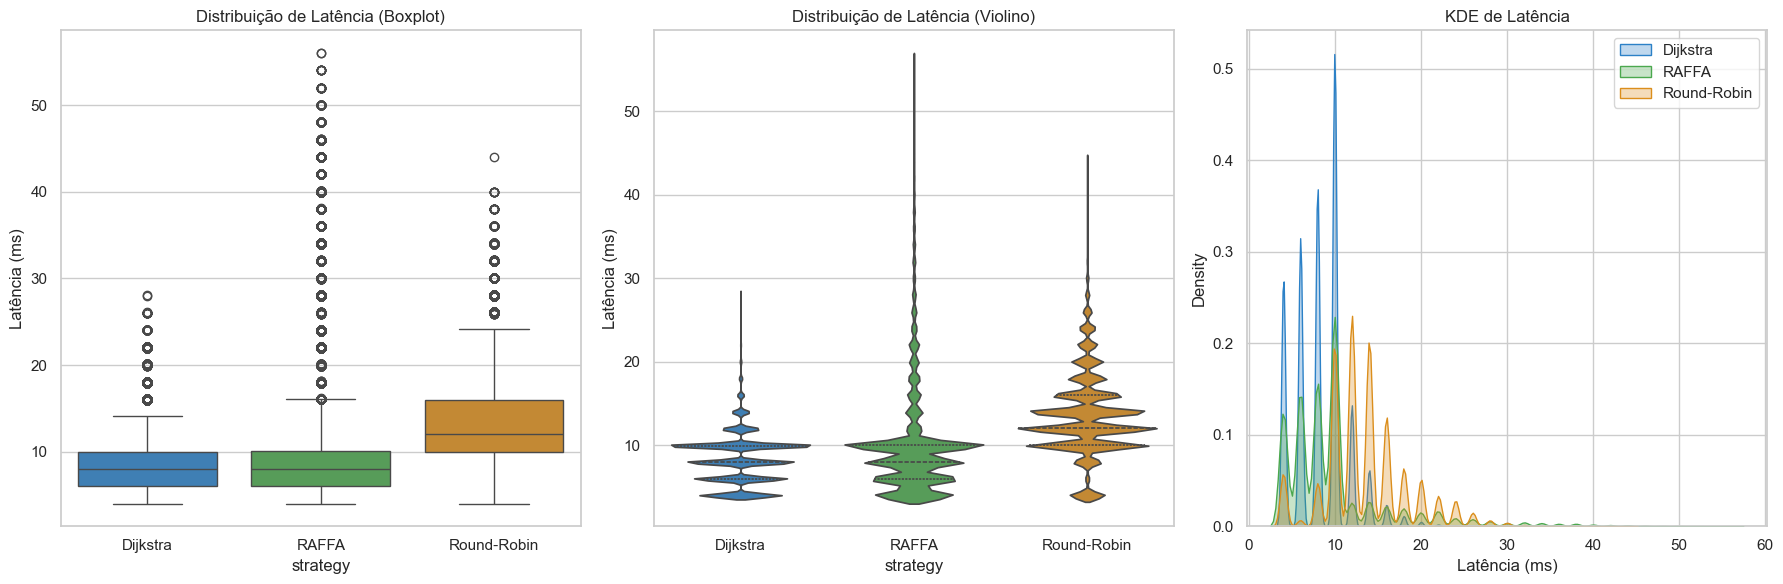

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2a – Box plot
sns.boxplot(x="strategy", y="Latency", data=df_all, palette=STRATEGY_PALETTE, ax=axes[0])
axes[0].set_title(T("title_lat_box"))
axes[0].set_ylabel(T("latency_ms"))

# 2b – Violin plot
sns.violinplot(x="strategy", y="Latency", data=df_all, palette=STRATEGY_PALETTE, inner="quartile", ax=axes[1])
axes[1].set_title(T("title_lat_violin"))
axes[1].set_ylabel(T("latency_ms"))

# 2c – Histogram / KDE overlay
for strat in strategies:
    if strat in dfs:
        sns.kdeplot(dfs[strat]["Latency"], label=S(strat), color=STRATEGY_PALETTE[S(strat)], ax=axes[2], fill=True, alpha=0.3)
axes[2].set_title(T("title_lat_kde"))
axes[2].set_xlabel(T("latency_ms"))
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Latência Média por Estratégia
*Mean Latency per Strategy*

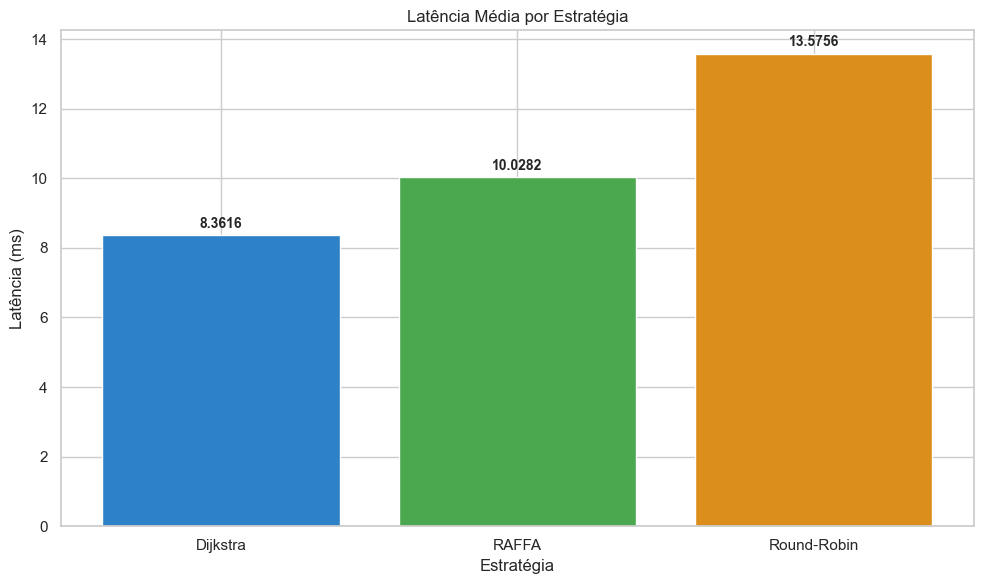

,Latência (ms)
strategy,
Dijkstra,8.3616
RAFFA,10.0282
Round-Robin,13.5756


In [116]:
# Mean Latency per strategy
mean_latency = (
    df_all.groupby("strategy")["Latency"]
    .mean()
    .reindex(strategies_display)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(mean_latency.index, mean_latency.values,
              color=[STRATEGY_PALETTE[s] for s in mean_latency.index])

for bar, val in zip(bars, mean_latency.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + mean_latency.max() * 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

ax.set_title(T("title_breakdown"))
ax.set_ylabel(T("latency_ms"))
ax.set_xlabel(T("strategy"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(mean_latency.round(4).to_frame(name=T("latency_ms")))

## 4. Latência ao Longo do Tempo (Por Estratégia)
*Latency Over Time (Per Strategy)*

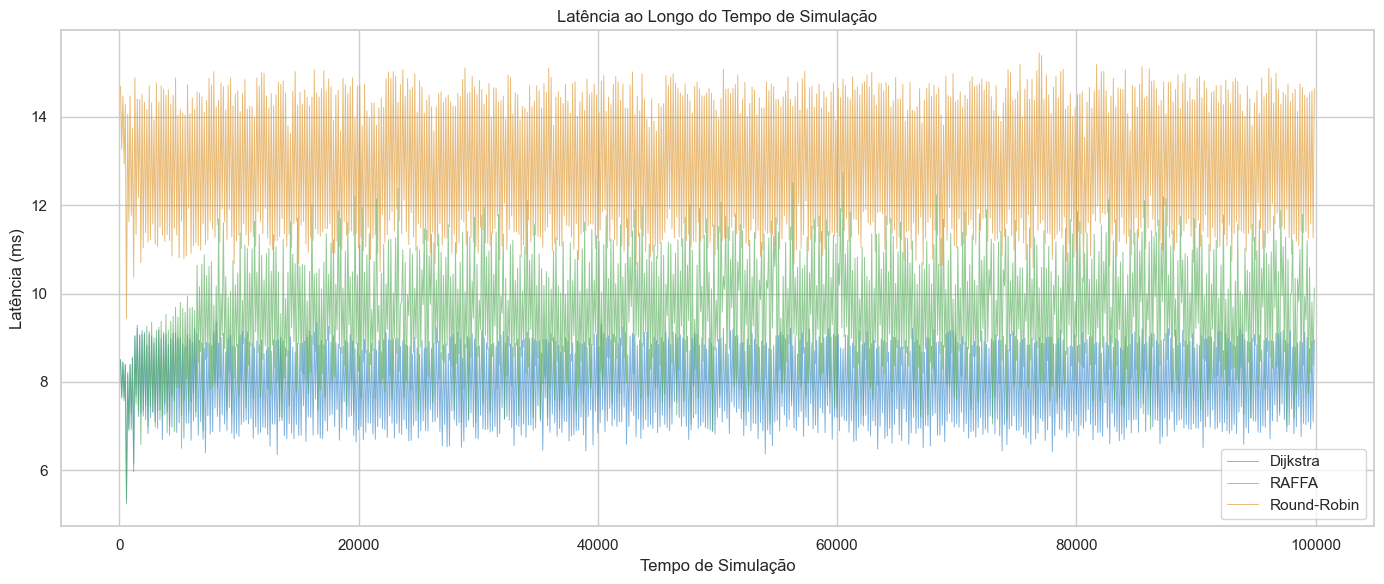

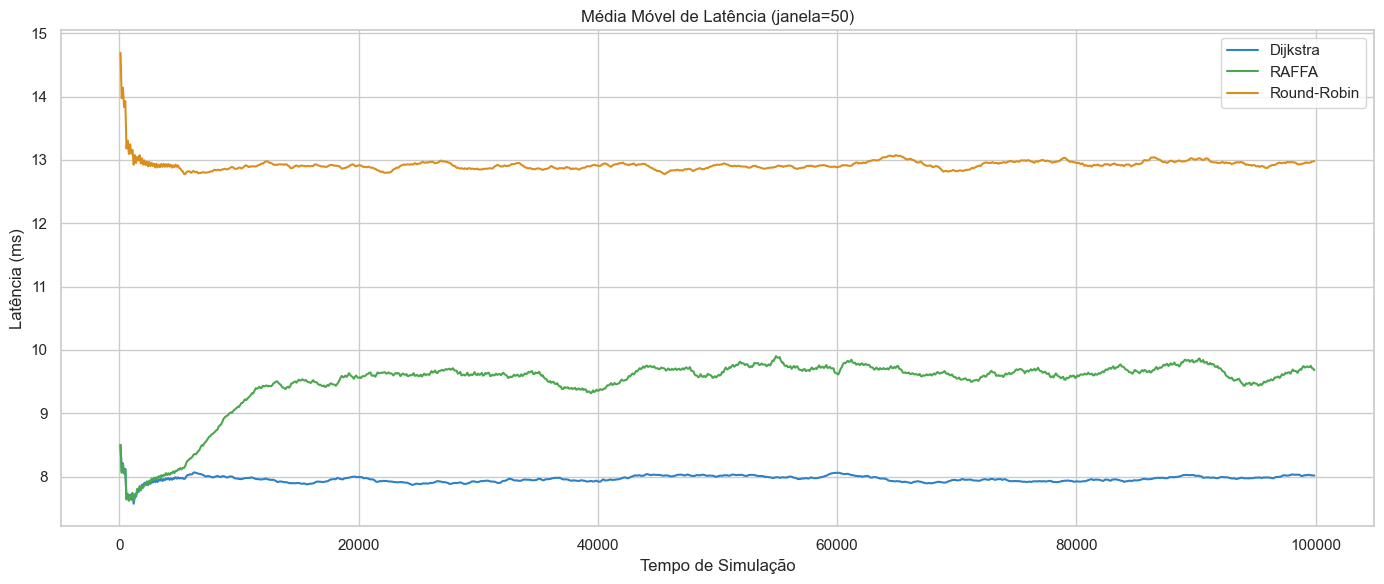

In [117]:
TIME_BIN = 100  # bin size for averaging across executions

# 4a – Raw latency over time (binned average for clarity with multi-execution data)
plt.figure(figsize=(14, 6))
for strat in strategies:
    if strat in dfs:
        d = dfs[strat].copy()
        d["time_bin"] = (d["time_reception"] // TIME_BIN) * TIME_BIN
        binned = d.groupby("time_bin")["Latency"].mean()
        plt.plot(binned.index, binned.values, label=S(strat),
                 color=STRATEGY_PALETTE[S(strat)], alpha=0.6, linewidth=0.7)
plt.title(T("title_lat_over_time"))
plt.xlabel(T("simulation_time"))
plt.ylabel(T("latency_ms"))
plt.legend()
plt.tight_layout()
plt.show()

# 4b – Rolling average latency (window = 50 bins)
plt.figure(figsize=(14, 6))
for strat in strategies:
    if strat in dfs:
        d = dfs[strat].copy()
        d["time_bin"] = (d["time_reception"] // TIME_BIN) * TIME_BIN
        binned = d.groupby("time_bin")["Latency"].mean().reset_index()
        binned["rolling_latency"] = binned["Latency"].rolling(window=50, min_periods=1).mean()
        plt.plot(binned["time_bin"], binned["rolling_latency"], label=S(strat),
                 color=STRATEGY_PALETTE[S(strat)], linewidth=1.5)
plt.title(T("title_rolling_lat"))
plt.xlabel(T("simulation_time"))
plt.ylabel(T("latency_ms"))
plt.legend()
plt.tight_layout()
plt.show()

## 5. Distribuição de Carga por Nó
*Per-Node Workload Distribution*

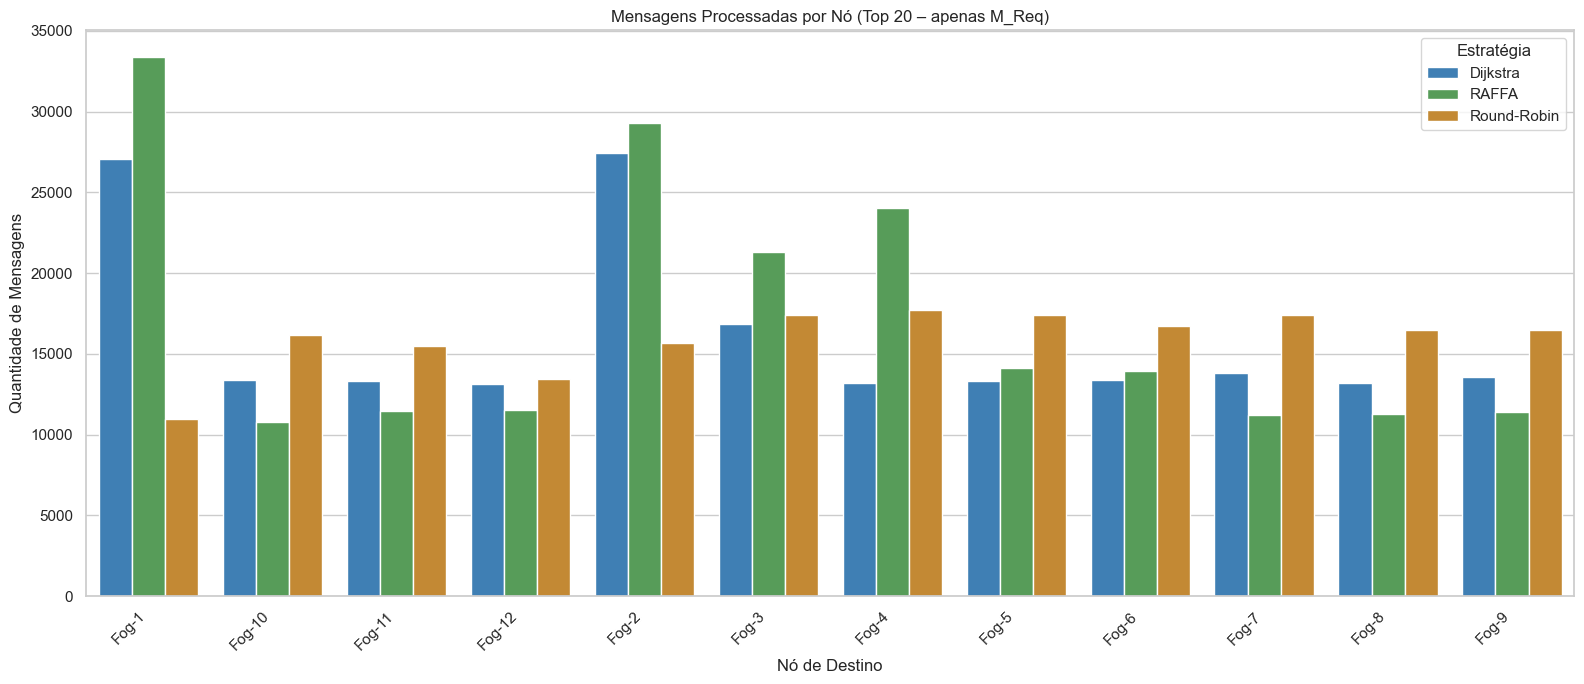

In [118]:
# Count messages handled by each destination node, per strategy (only M_Req)
df_req = df_all[df_all["message"] == "M_Req"]

node_workload = (
    df_req.groupby(["strategy", "TOPO.dstLabel"])
    .size()
    .reset_index(name="msg_count")
)

# Keep only top nodes by total messages for readability
top_nodes = (
    node_workload.groupby("TOPO.dstLabel")["msg_count"]
    .sum()
    .nlargest(20)
    .index
)
node_workload_top = node_workload[node_workload["TOPO.dstLabel"].isin(top_nodes)]

plt.figure(figsize=(16, 7))
sns.barplot(
    x="TOPO.dstLabel", y="msg_count", hue="strategy",
    data=node_workload_top, palette=STRATEGY_PALETTE,
    order=sorted(top_nodes)
)
plt.title(T("title_msgs_per_node"))
plt.xlabel(T("xlabel_dst_node"))
plt.ylabel(T("message_count"))
plt.xticks(rotation=45, ha="right")
plt.legend(title=T("strategy"))
plt.tight_layout()
plt.show()

## 6. Latência por Estratégia
*Latency by Strategy*

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/2208720746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


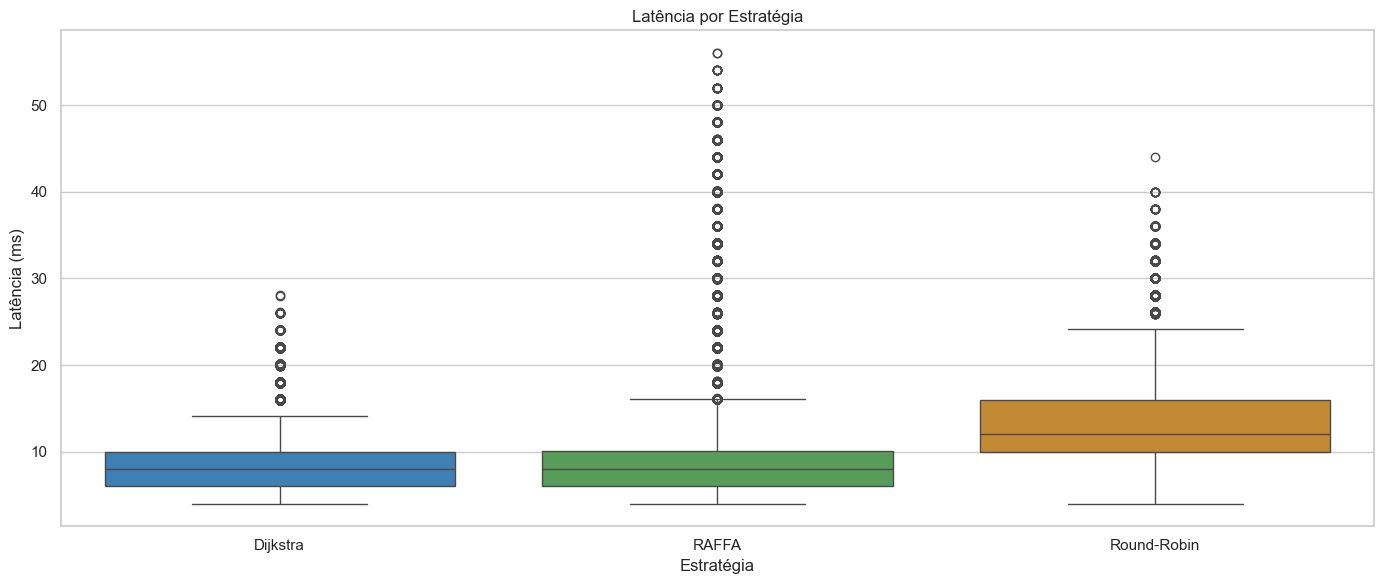

In [119]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    x="strategy", y="Latency",
    data=df_all, palette=STRATEGY_PALETTE
)
plt.title(T("title_lat_msg_type"))
plt.ylabel(T("latency_ms"))
plt.xlabel(T("strategy"))
plt.tight_layout()
plt.show()

## 7. Mensagens e Latência Acumuladas ao Longo do Tempo
*Cumulative Messages & Latency Over Time*

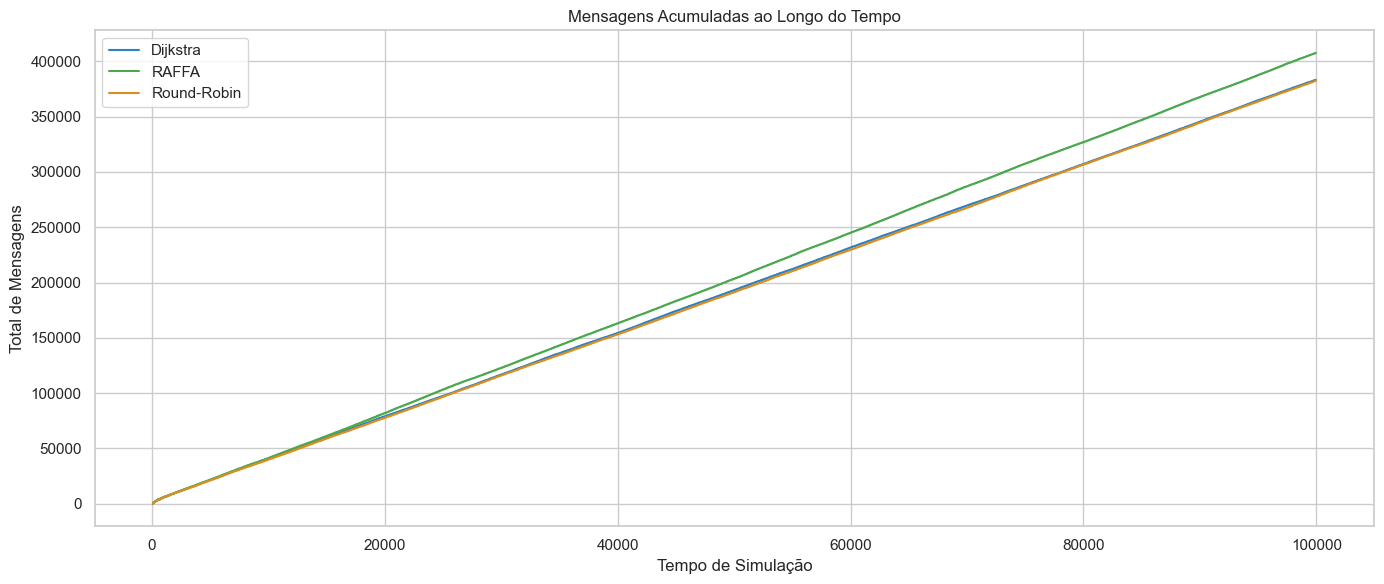

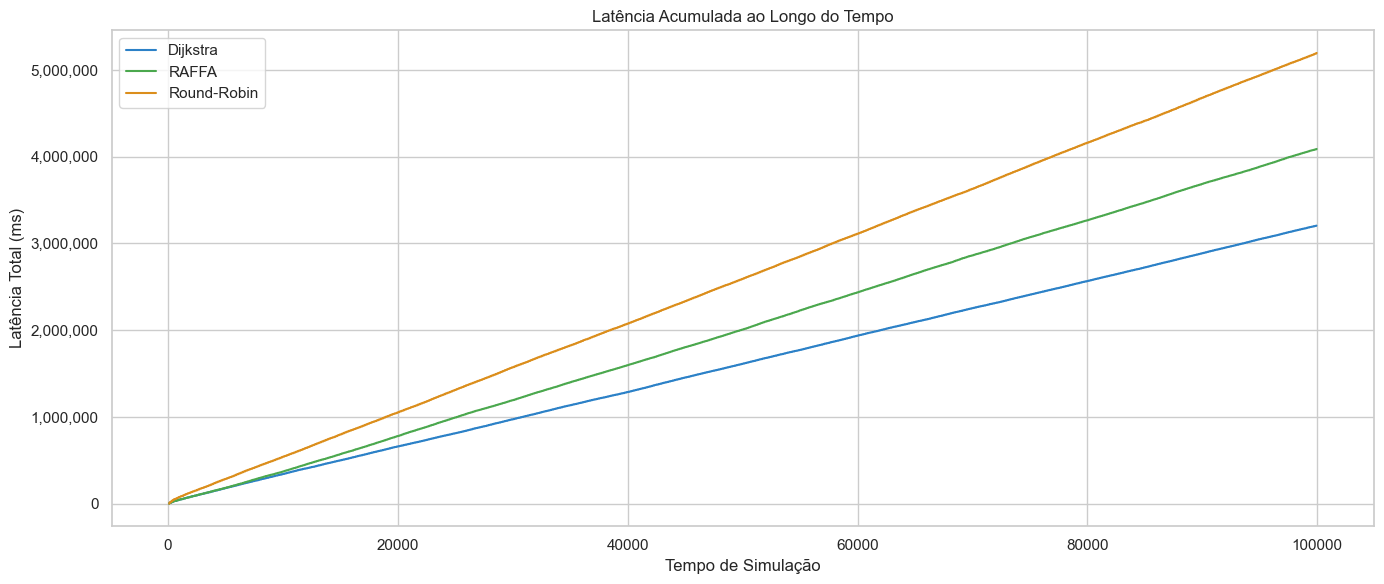

In [120]:
# 7a – Cumulative messages over time
plt.figure(figsize=(14, 6))
for strat in strategies:
    if strat in dfs:
        d = dfs[strat].sort_values("time_reception").copy()
        d["cum_msgs"] = np.arange(1, len(d) + 1)
        plt.plot(d["time_reception"], d["cum_msgs"], label=S(strat),
                 color=STRATEGY_PALETTE[S(strat)])
plt.title(T("title_cum_msgs"))
plt.xlabel(T("simulation_time"))
plt.ylabel(T("ylabel_total_msgs"))
plt.legend()
plt.tight_layout()
plt.show()

# 7b – Cumulative latency over time
plt.figure(figsize=(14, 6))
for strat in strategies:
    if strat in dfs:
        d = dfs[strat].sort_values("time_reception").copy()
        d["cum_latency"] = d["Latency"].cumsum()
        plt.plot(d["time_reception"], d["cum_latency"], label=S(strat),
                 color=STRATEGY_PALETTE[S(strat)])
plt.title(T("title_cum_lat"))
plt.xlabel(T("simulation_time"))
plt.ylabel(T("ylabel_total_lat"))
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mapas de Calor de Comunicação (Origem → Destino)
*Communication Heatmaps (Source → Destination)*

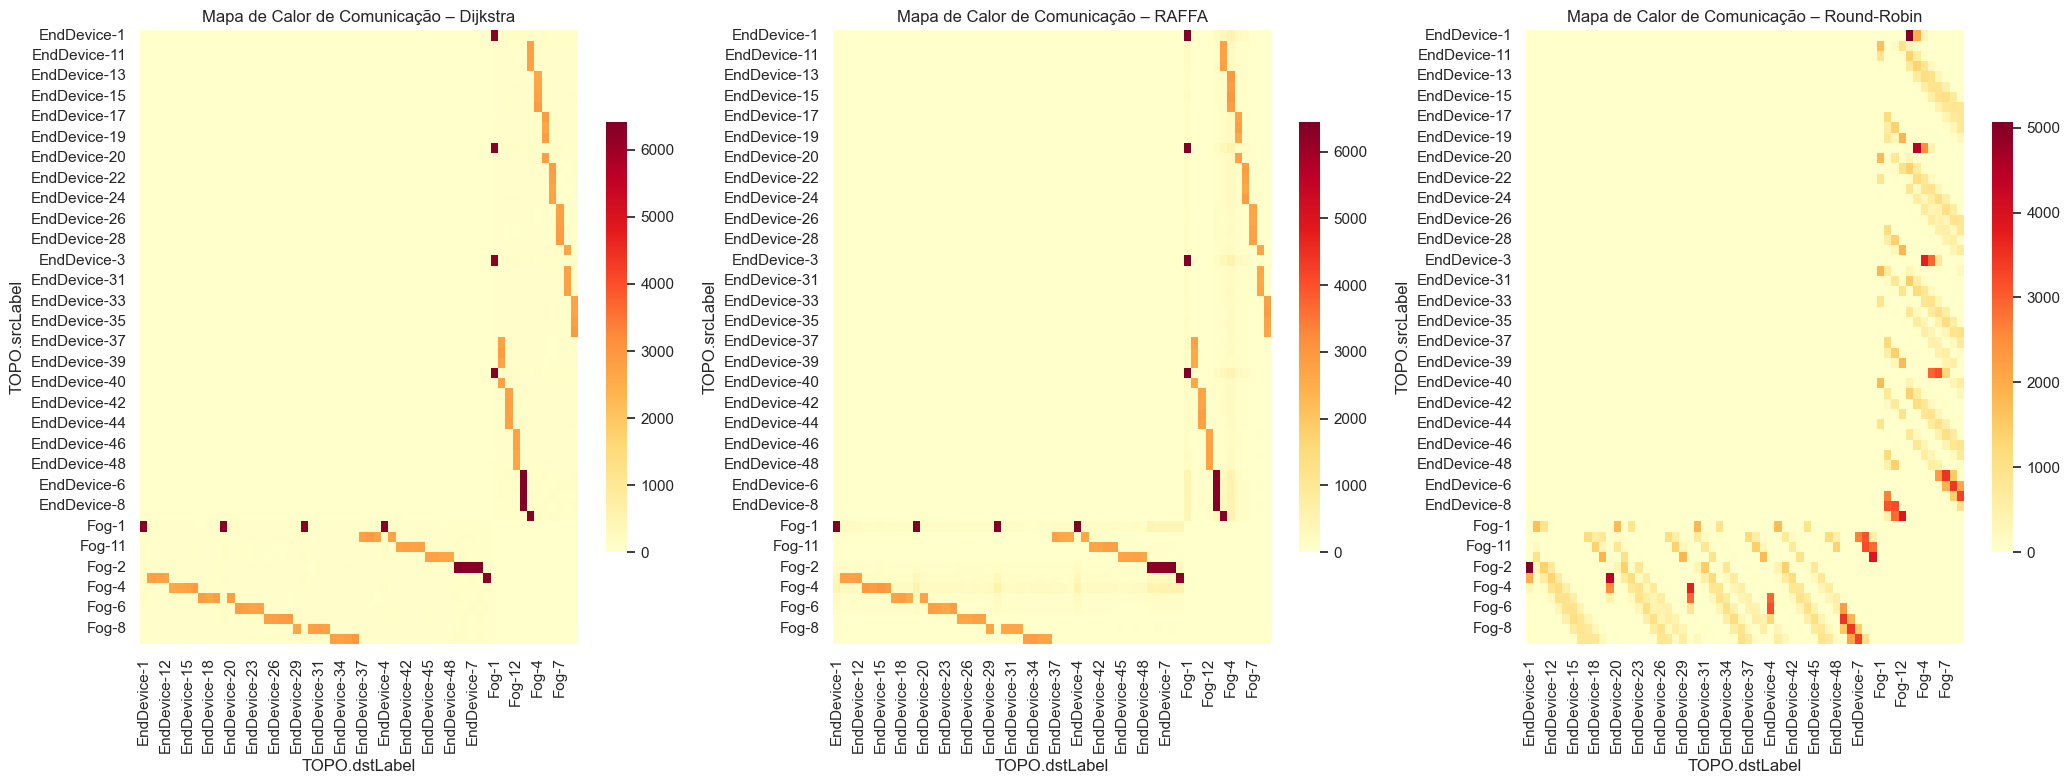

In [121]:
fig, axes = plt.subplots(1, len(strategies), figsize=(7 * len(strategies), 8))
if len(strategies) == 1:
    axes = [axes]

for ax, strat in zip(axes, strategies):
    if strat in dfs:
        ct = pd.crosstab(dfs[strat]["TOPO.srcLabel"], dfs[strat]["TOPO.dstLabel"])
        if ct.empty or ct.values.sum() == 0:
            ax.set_title(T("title_heatmap", strat=S(strat)) + T("no_data_suffix"))
            ax.text(0.5, 0.5, T("no_comm_data"), ha="center", va="center", transform=ax.transAxes)
        else:
            sns.heatmap(ct, cmap="YlOrRd", annot=False, fmt="d", ax=ax, cbar_kws={"shrink": 0.7})
            ax.set_title(T("title_heatmap", strat=S(strat)))
            ax.tick_params(axis='x', rotation=90)
            ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 9. Comparação de Falhas
*Failure Comparison*

,Falhas (avg),Std,N
Estratégia,,,
Dijkstra,2945.9,65.0,10
RAFFA,243.9,44.0,10
Round-Robin,2920.3,110.1,10


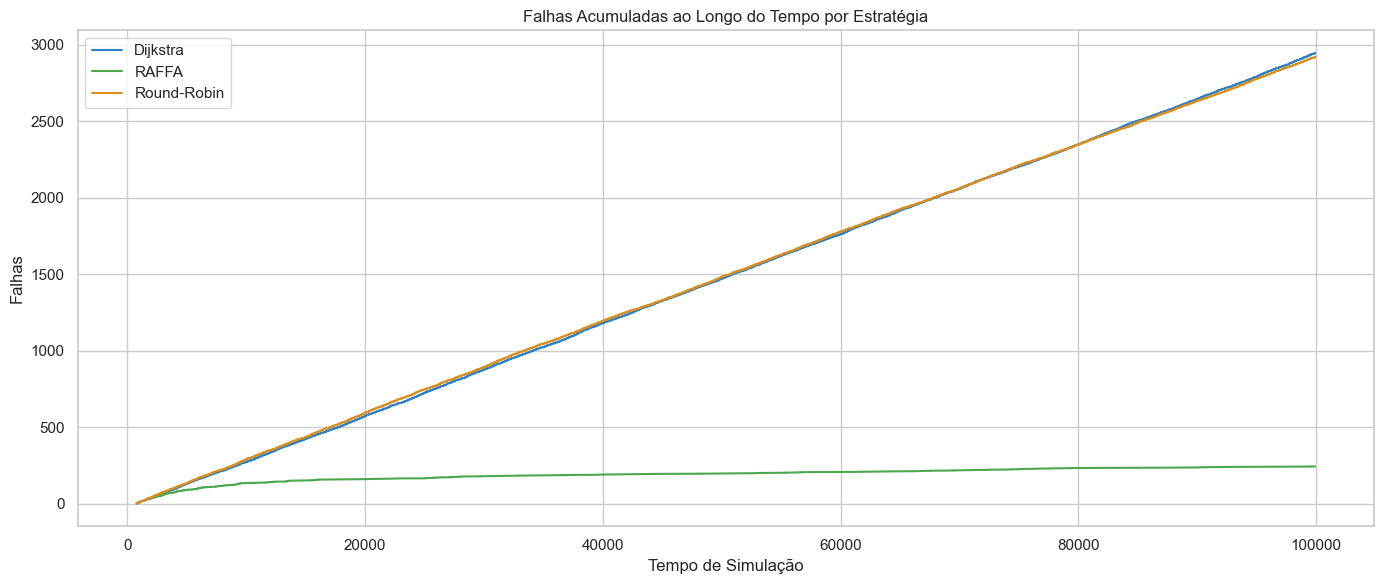

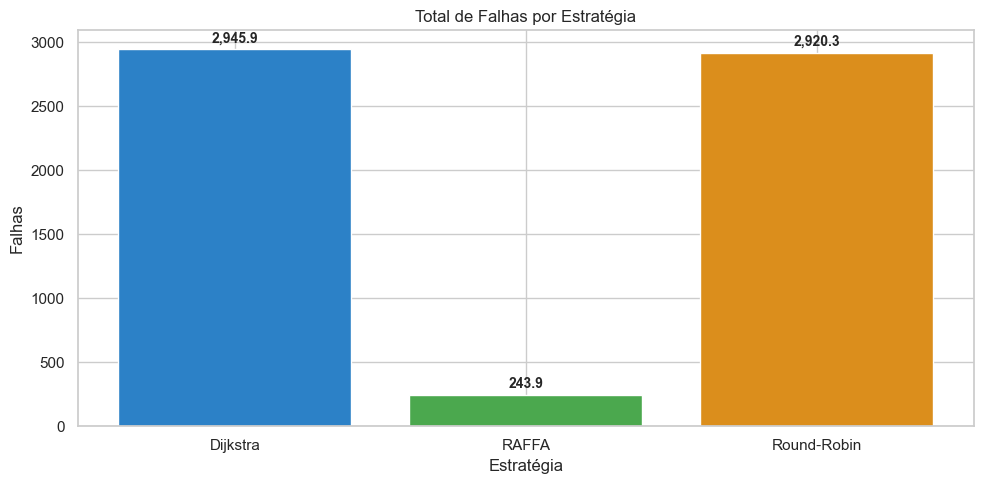

In [122]:
if dfs_failure:
    df_fail_all = pd.concat(dfs_failure.values(), ignore_index=True)

    # Summary table – average failures per execution (not total)
    fail_records = []
    for strat in strategies:
        if strat in all_strategy_data:
            info = all_strategy_data[strat]
            df_e = pd.DataFrame(info["records"])
            n = info["n"]
            avg_fail = df_e[T("col_failures")].mean()
            std_fail = df_e[T("col_failures")].std() if n > 1 else 0
            fail_records.append({
                T("strategy"): S(strat),
                T("col_failures") + " (avg)": round(avg_fail, 1),
                "Std": round(std_fail, 1) if n > 1 else "—",
                "N": n,
            })
    fail_summary = pd.DataFrame(fail_records).set_index(T("strategy"))
    display(fail_summary)

    # Failures over time per strategy (average across executions)
    time_col = None
    for candidate in ["ctime", "time", "time_reception", "timestamp"]:
        if candidate in df_fail_all.columns:
            time_col = candidate
            break

    if time_col:
        plt.figure(figsize=(14, 6))
        for strat in strategies:
            if strat not in dfs_failure:
                continue
            n_exec = all_strategy_data[strat]["n"] if strat in all_strategy_data else 1
            df_s = dfs_failure[strat].sort_values(time_col).copy()
            df_s["cum_failures"] = np.arange(1, len(df_s) + 1) / n_exec
            plt.plot(df_s[time_col], df_s["cum_failures"], label=S(strat),
                     color=STRATEGY_PALETTE[S(strat)])
        plt.title(T("title_fail_over_time"))
        plt.xlabel(T("simulation_time"))
        plt.ylabel(T("failures"))
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 9b – Average failures bar chart
    avg_failures = fail_summary[T("col_failures") + " (avg)"]
    plt.figure(figsize=(10, 5))
    bars = plt.bar(avg_failures.index, avg_failures.values,
                   color=[STRATEGY_PALETTE.get(s, "gray") for s in avg_failures.index])
    for bar, val in zip(bars, avg_failures.values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + avg_failures.max() * 0.01,
                 f"{val:,.1f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
    plt.title(T("title_total_failures"))
    plt.ylabel(T("failures"))
    plt.xlabel(T("strategy"))
    plt.tight_layout()
    plt.show()
else:
    print(T("no_failure_data"))

## 10. Contagem de Nós ao Longo do Tempo
*Node Counts Over Time*

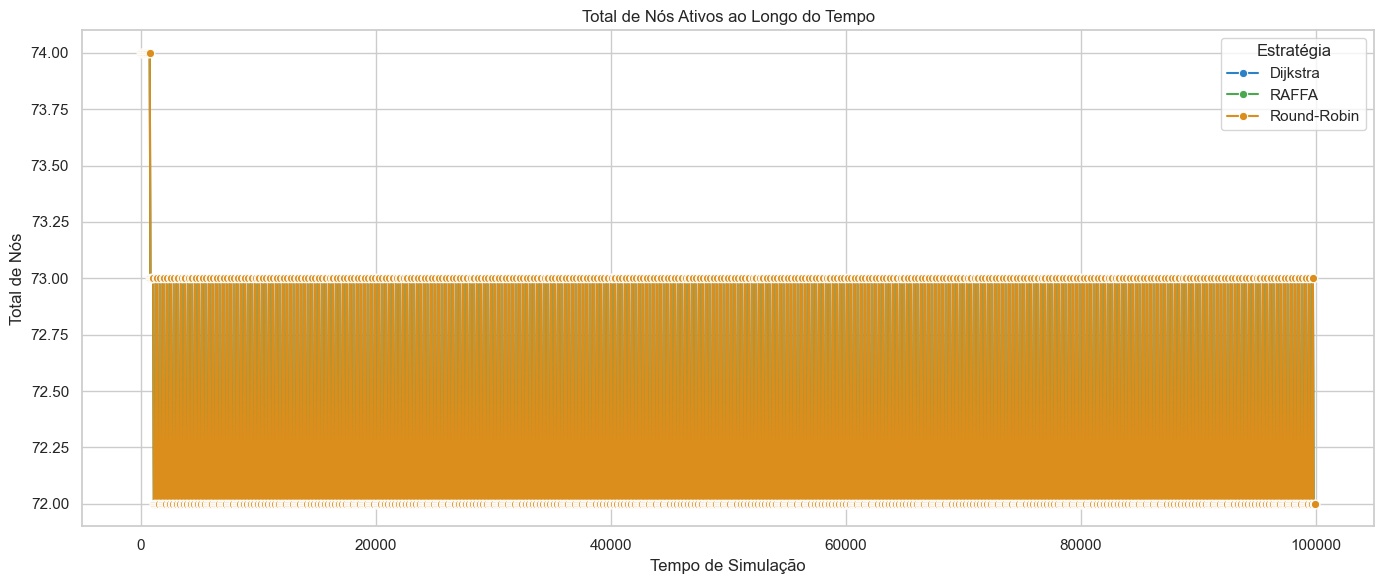

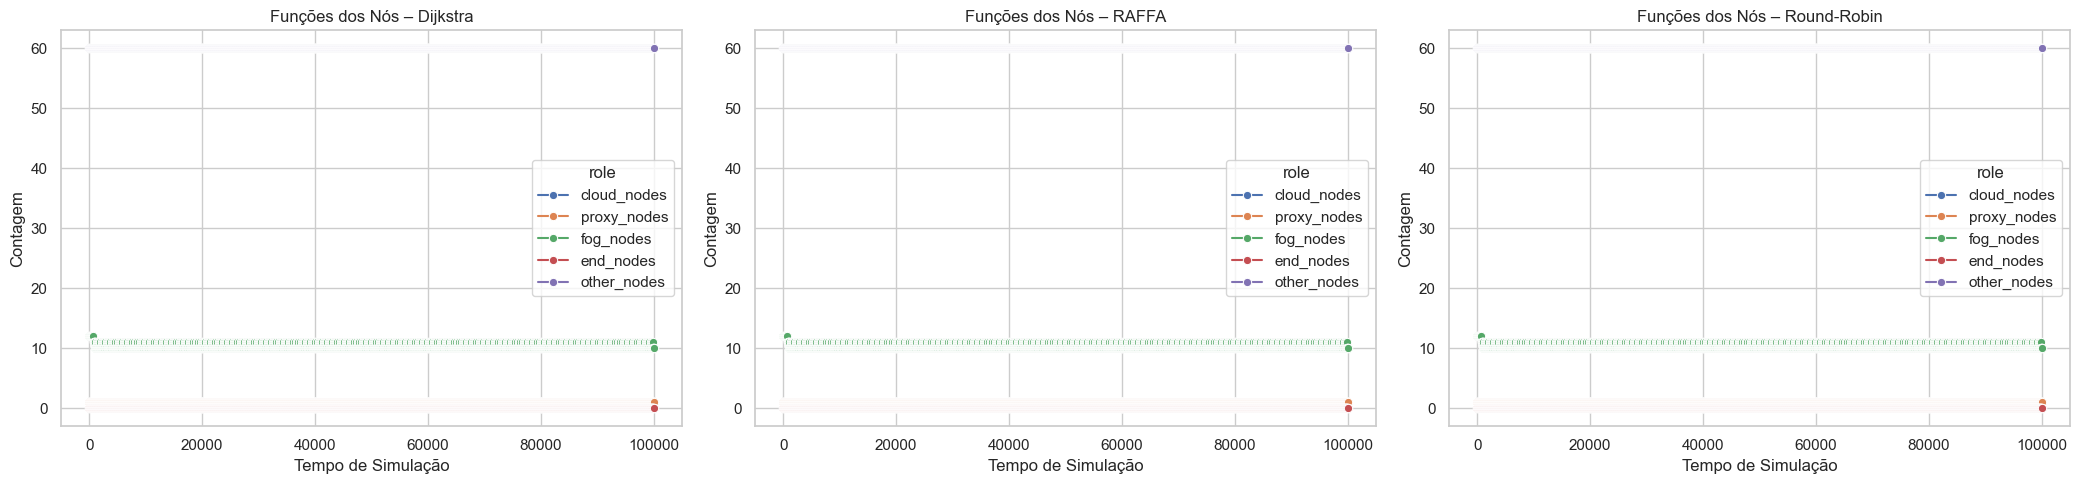

In [123]:
if dfs_node_counts:
    df_nc_all = pd.concat(dfs_node_counts.values(), ignore_index=True)

    value_cols = [
        col for col in ["total_nodes", "cloud_nodes", "proxy_nodes",
                        "fog_nodes", "end_nodes", "other_nodes"]
        if col in df_nc_all.columns
    ]

    if "total_nodes" in df_nc_all.columns:
        plt.figure(figsize=(14, 6))
        sns.lineplot(
            x="time", y="total_nodes", hue="strategy",
            data=df_nc_all, palette=STRATEGY_PALETTE, marker="o"
        )
        plt.title(T("title_total_nodes"))
        plt.xlabel(T("simulation_time"))
        plt.ylabel(T("ylabel_total_nodes"))
        plt.legend(title=T("strategy"))
        plt.tight_layout()
        plt.show()

    # Per-role breakdown for each strategy
    role_cols = [c for c in value_cols if c != "total_nodes"]
    if role_cols:
        fig, axes = plt.subplots(1, len(strategies), figsize=(7 * len(strategies), 5))
        if len(strategies) == 1:
            axes = [axes]
        for ax, strat in zip(axes, strategies):
            if strat in dfs_node_counts:
                nc = dfs_node_counts[strat]
                melted = nc.melt(id_vars="time", value_vars=role_cols,
                                 var_name="role", value_name="count")
                sns.lineplot(x="time", y="count", hue="role", data=melted,
                             marker="o", ax=ax)
                ax.set_title(T("title_node_roles", strat=S(strat)))
                ax.set_xlabel(T("simulation_time"))
                ax.set_ylabel(T("count"))
        plt.tight_layout()
        plt.show()
else:
    print(T("no_node_count"))

## 11. Tabela Resumo
*Summary Table*

Uma tabela única reunindo os principais KPIs por estratégia.
*A single table collecting the key KPIs per strategy.*

In [124]:
records = []
for strat in strategies:
    if strat not in dfs:
        continue
    d = dfs[strat]
    rec = {
        T("strategy"): S(strat),
        T("col_total_msgs"): len(d),
        T("col_mean_lat"): round(d["Latency"].mean(), 4),
        T("col_median_lat"): round(d["Latency"].median(), 4),
        T("col_p95_lat"): round(d["Latency"].quantile(0.95), 4),
        T("col_p99_lat"): round(d["Latency"].quantile(0.99), 4),
        T("col_std_lat"): round(d["Latency"].std(), 4),
        T("col_mean_svc"): round(d["Service_Time"].mean(), 4),
        T("col_mean_net"): round(d["Network_Time"].mean(), 4),
        T("col_failures"): len(dfs_failure.get(strat, pd.DataFrame())),
    }
    records.append(rec)

summary_df = pd.DataFrame(records).set_index(T("strategy"))
display(summary_df)

,Total de Mensagens,Latência Média (ms),Latência Mediana (ms),Latência P95 (ms),Latência P99 (ms),Desvio Padrão (ms),Tempo Médio de Serviço (ms),Tempo Médio de Rede (ms),Falhas
Estratégia,,,,,,,,,
Dijkstra,383344,8.3616,8.0307,13.9731,17.9746,3.0032,0.0184,8.3432,29459
RAFFA,407682,10.0282,8.0514,23.9684,36.0292,6.3691,0.0173,10.0109,2439
Round-Robin,382694,13.5756,12.0677,24.0167,28.0242,4.8609,0.0194,13.5561,29203


---

# Métricas Estendidas (Seções 13–21)
*Extended Metrics (Sections 13–21)*

As seções abaixo utilizam fontes de dados adicionais (`sim_trace_link.csv`, atributos da topologia, `unprocessed_messages.csv`) para proporcionar comparações mais aprofundadas entre as estratégias.

*The sections below leverage additional data sources to provide deeper comparisons between strategies.*

## 13. Decomposição da Latência: Rede vs Fila vs Processamento
*Latency Decomposition: Network vs Queue vs Processing*

Decomposição do tempo total de resposta em três componentes:
- **Latência de rede** (`time_reception − time_emit`): tempo gasto traversando a rede
- **Espera na fila** (`time_in − time_reception`): tempo aguardando na fila de processamento
- **Tempo de serviço** (`time_out − time_in`): processamento efetivo no módulo

*Break total response time into three components: network latency, queue wait, and service time.*

,Rede (ms),Espera na Fila (ms),Processamento (ms),Total (ms)
Estratégia,,,,
Dijkstra,8.3432,0.0,0.0184,8.3616
RAFFA,10.0109,0.0,0.0173,10.0282
Round-Robin,13.5561,0.0,0.0194,13.5756


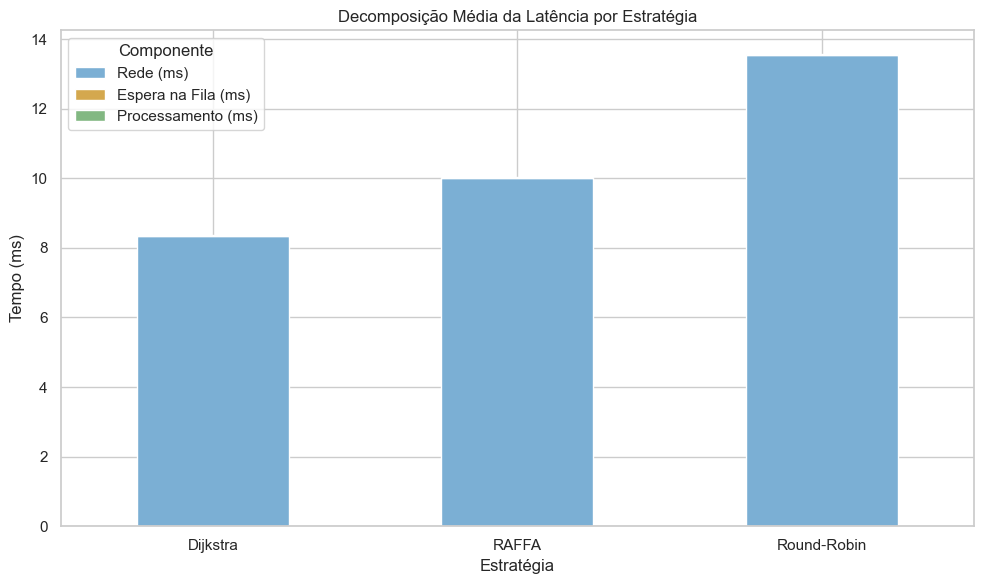

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/3626093174.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="strategy", y="time_network", data=df_all, palette=STRATEGY_PALETTE)


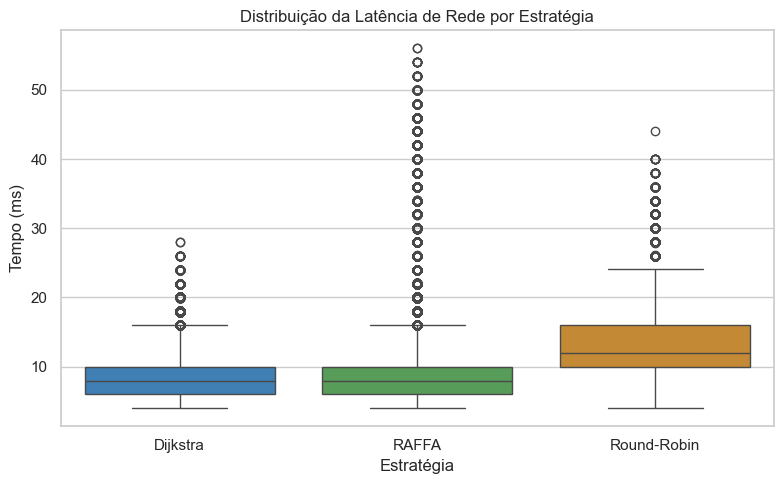

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/3626093174.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="strategy", y="time_queue", data=df_all, palette=STRATEGY_PALETTE)


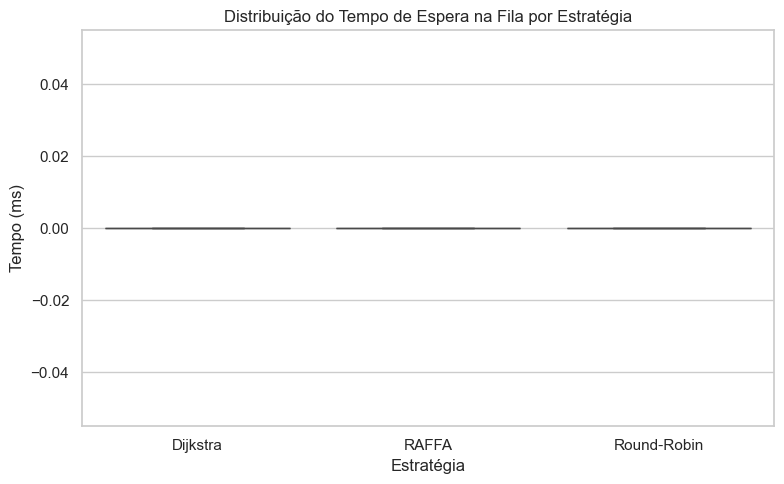

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/3626093174.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="strategy", y="Service_Time", data=df_all, palette=STRATEGY_PALETTE)


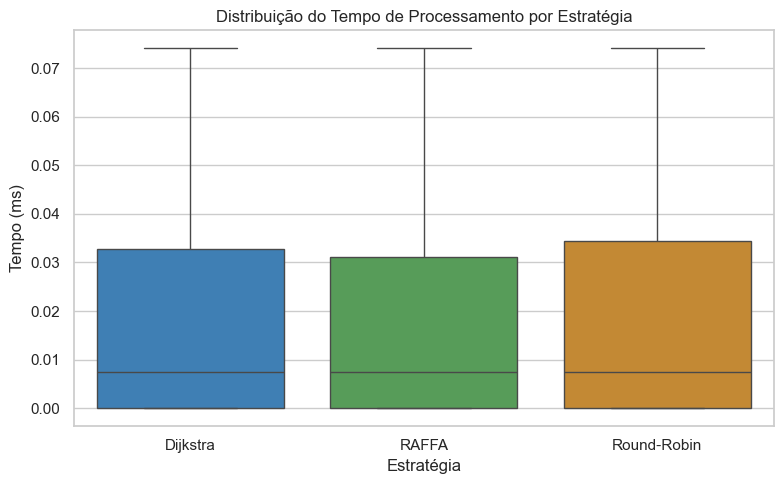

In [125]:
# Decompose latency into network, queue, and processing components
for strat in strategies:
    if strat in dfs:
        d = dfs[strat]
        d["time_network"] = d["time_reception"] - d["time_emit"]
        d["time_queue"]   = d["time_in"] - d["time_reception"]

# Rebuild df_all with new columns
df_all = pd.concat(dfs.values(), ignore_index=True)

# Build decomposition table
decomp_records = []
for strat in strategies:
    if strat in dfs:
        d = dfs[strat]
        decomp_records.append({
            T("strategy"): S(strat),
            T("col_network"): d["time_network"].mean(),
            T("col_queue_wait"): d["time_queue"].mean(),
            T("col_processing"): d["Service_Time"].mean(),
            T("col_total"): d["Latency"].mean(),
        })

df_decomp = pd.DataFrame(decomp_records).set_index(T("strategy")).reindex(strategies_display).dropna()
display(df_decomp.round(4))

# Stacked bar
df_decomp[[T("col_network"), T("col_queue_wait"), T("col_processing")]].plot(
    kind="bar", stacked=True, color=["#7BAFD4", "#D4A84E", "#82B882"], figsize=(10, 6)
)
plt.title(T("title_decomp"))
plt.ylabel(T("time_ms"))
plt.xlabel(T("strategy"))
plt.xticks(rotation=0)
plt.legend(title=T("component"))
plt.tight_layout()
plt.show()

# Box plot: Network Latency
plt.figure(figsize=(8, 5))
sns.boxplot(x="strategy", y="time_network", data=df_all, palette=STRATEGY_PALETTE)
plt.title(T("title_net_lat_dist"))
plt.ylabel(T("time_ms"))
plt.xlabel(T("strategy"))
plt.tight_layout()
plt.show()

# Box plot: Queue Wait Time
plt.figure(figsize=(8, 5))
sns.boxplot(x="strategy", y="time_queue", data=df_all, palette=STRATEGY_PALETTE)
plt.title(T("title_queue_dist"))
plt.ylabel(T("time_ms"))
plt.xlabel(T("strategy"))
plt.tight_layout()
plt.show()

# Box plot: Processing Time
plt.figure(figsize=(8, 5))
sns.boxplot(x="strategy", y="Service_Time", data=df_all, palette=STRATEGY_PALETTE)
plt.title(T("title_proc_dist"))
plt.ylabel(T("time_ms"))
plt.xlabel(T("strategy"))
plt.tight_layout()
plt.show()

## 14. Métricas de Rede a Nível de Link (Congestionamento, Largura de Banda, Saltos)
*Link-Level Network Metrics (Congestion, Bandwidth, Hops)*

Carrega `sim_trace_link.csv` para analisar:
- **Congestionamento de rede** (`buffer` = mensagens em trânsito)
- **Atraso de fila por salto** (`wait`)
- **Total de bytes transmitidos** (`size`)
- **Média de saltos por mensagem** (linhas de link por ID de mensagem)

*Load `sim_trace_link.csv` to analyze network congestion, queuing delay, bytes transmitted, and hops per message.*

In [126]:
# Load link traces for all strategies
dfs_link = {}
for strat in strategies:
    lp = Path(f"results/{file_base}-{strat}-sim_trace_link.csv")
    if lp.exists():
        dl = pd.read_csv(lp)
        dl["strategy"] = S(strat)
        dfs_link[strat] = dl
        print(f"✅ link {S(strat)}: {len(dl):,} rows")
    else:
        print(f"⚠️  link {S(strat)}: not found")

df_link_all = pd.concat(dfs_link.values(), ignore_index=True) if dfs_link else pd.DataFrame()
print(f"\nCombined link data: {len(df_link_all):,} rows")

✅ link Dijkstra: 1,239,716 rows
✅ link RAFFA: 1,396,810 rows
✅ link Round-Robin: 2,104,032 rows

Combined link data: 4,740,558 rows


,Total Link Events,Total Bytes Tx,Avg Hops/Msg,Avg Link Latency (ms),Avg Link Wait (ms),Avg Buffer (in-flight),Peak Buffer
Estratégia,,,,,,,
Dijkstra,1239716,12469211264,32.3652,2.0,1.5300,24.6449,47
RAFFA,1396810,14024303254,36.4607,2.0,2.1268,25.7586,47
Round-Robin,2104032,21150217974,54.8997,2.0,1.5798,26.3331,47


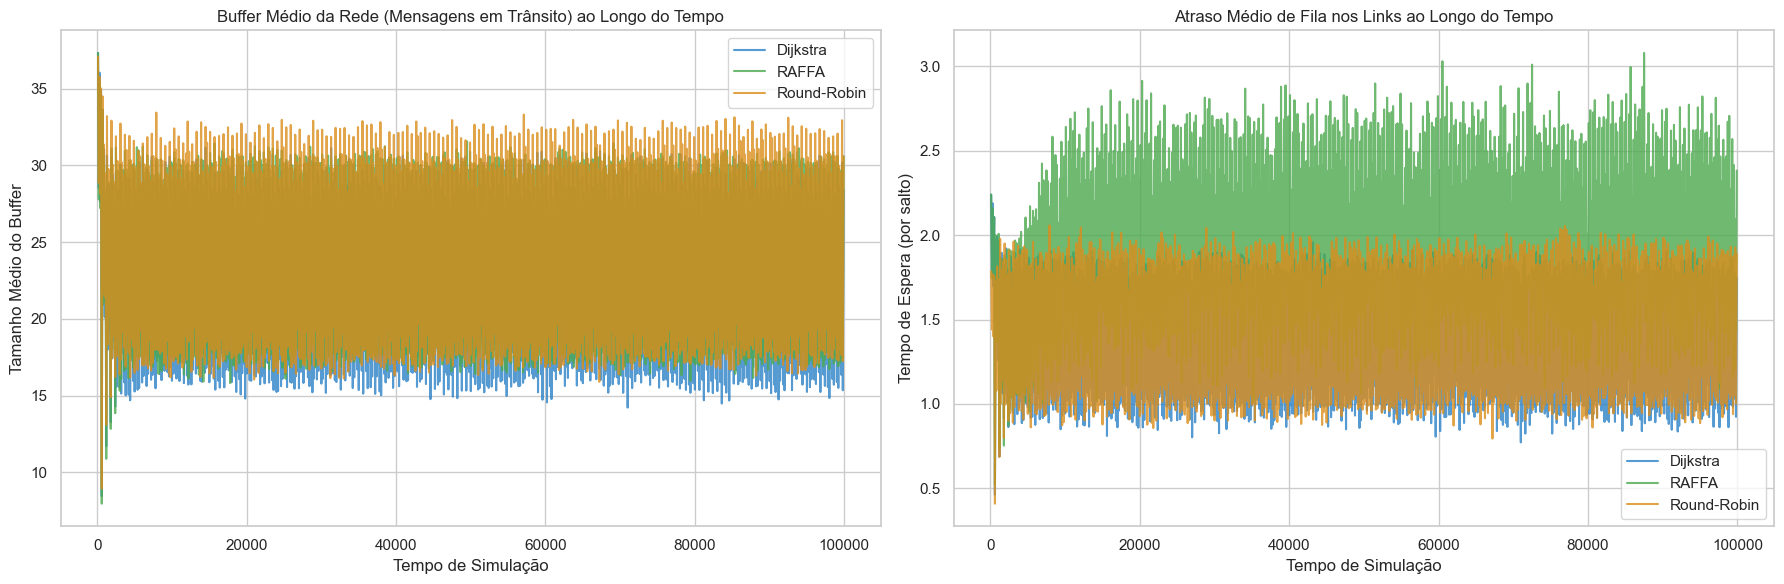

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_18696/2123974475.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="strategy", y="hops", data=df_hops, palette=STRATEGY_PALETTE)


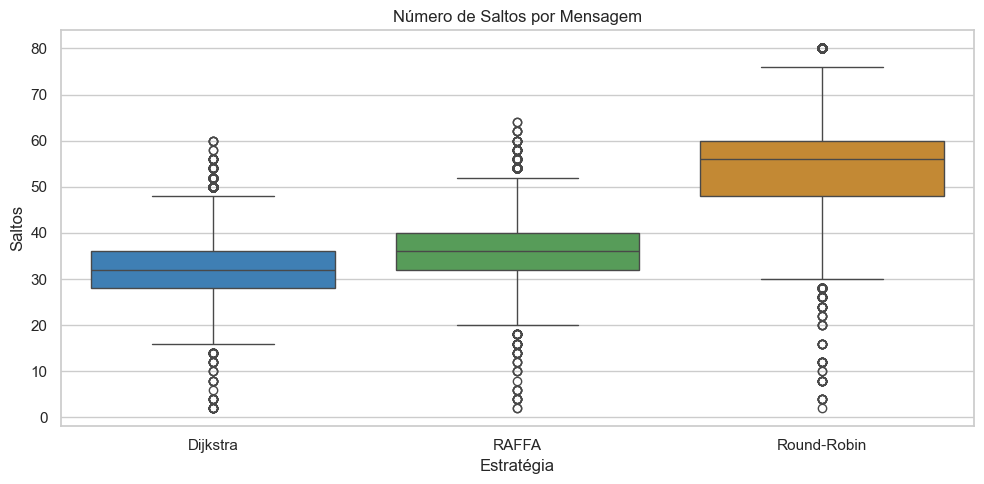

In [127]:
if not df_link_all.empty:
    # --- Link-level summary table ---
    link_summary_records = []
    for strat in strategies:
        if strat not in dfs_link:
            continue
        dl = dfs_link[strat]
        hops_per_msg = dl.groupby("id").size()
        link_summary_records.append({
            T("strategy"): S(strat),
            "Total Link Events": len(dl),
            "Total Bytes Tx": dl["size"].sum(),
            "Avg Hops/Msg": hops_per_msg.mean(),
            "Avg Link Latency (ms)": dl["latency"].mean(),
            "Avg Link Wait (ms)": dl["wait"].mean(),
            "Avg Buffer (in-flight)": dl["buffer"].mean(),
            "Peak Buffer": dl["buffer"].max(),
        })
    df_link_summary = pd.DataFrame(link_summary_records).set_index(T("strategy"))
    display(df_link_summary.round(4))

    # --- Network congestion over time ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Buffer (in-flight messages) over time
    for strat in strategies:
        if strat in dfs_link:
            dl = dfs_link[strat].sort_values("ctime")
            dl["time_bin"] = (dl["ctime"] // 100) * 100
            buf_over_time = dl.groupby("time_bin")["buffer"].mean()
            axes[0].plot(buf_over_time.index, buf_over_time.values,
                         label=S(strat), color=STRATEGY_PALETTE[S(strat)], alpha=0.8)
    axes[0].set_title(T("title_buffer_over_time"))
    axes[0].set_xlabel(T("simulation_time"))
    axes[0].set_ylabel(T("ylabel_avg_buffer"))
    axes[0].legend()

    # Queuing/wait time per hop over time
    for strat in strategies:
        if strat in dfs_link:
            dl = dfs_link[strat].sort_values("ctime")
            dl["time_bin"] = (dl["ctime"] // 100) * 100
            wait_over_time = dl.groupby("time_bin")["wait"].mean()
            axes[1].plot(wait_over_time.index, wait_over_time.values,
                         label=S(strat), color=STRATEGY_PALETTE[S(strat)], alpha=0.8)
    axes[1].set_title(T("title_link_queue_delay"))
    axes[1].set_xlabel(T("simulation_time"))
    axes[1].set_ylabel(T("ylabel_wait_per_hop"))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Average hops per message ---
    hops_data = []
    for strat in strategies:
        if strat in dfs_link:
            h = dfs_link[strat].groupby("id").size().reset_index(name="hops")
            h["strategy"] = S(strat)
            hops_data.append(h)
    if hops_data:
        df_hops = pd.concat(hops_data, ignore_index=True)
        plt.figure(figsize=(10, 5))
        sns.boxplot(x="strategy", y="hops", data=df_hops, palette=STRATEGY_PALETTE)
        plt.title(T("title_hops_per_msg"))
        plt.ylabel(T("hops"))
        plt.xlabel(T("strategy"))
        plt.tight_layout()
        plt.show()
else:
    print(T("no_link_data"))

## 15. Porcentagem de Mensagens Enviadas com Sucesso (Confiabilidade)
*Percentage of Successfully Sent Messages (Reliability)*

Compara a **taxa de sucesso** de cada estratégia: qual fração das mensagens geradas completou o processamento vs. falhou?

*Compare the success rate of each strategy: what fraction of generated messages completed processing vs. failed?*

,Entregues,Com Falha,Total Gerado,Taxa de Entrega (%)
Estratégia,,,,
Dijkstra,383344,29459,412803,92.86
RAFFA,407682,2439,410121,99.41
Round-Robin,382694,29203,411897,92.91


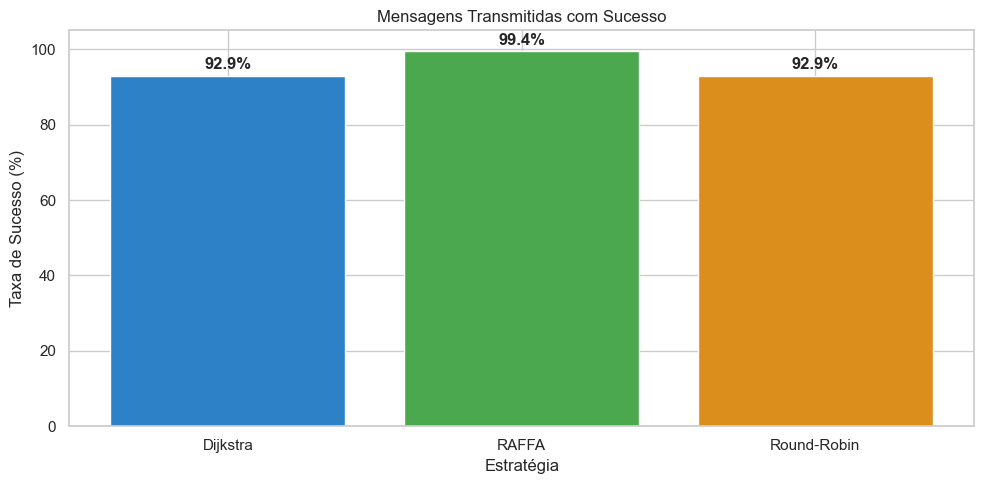

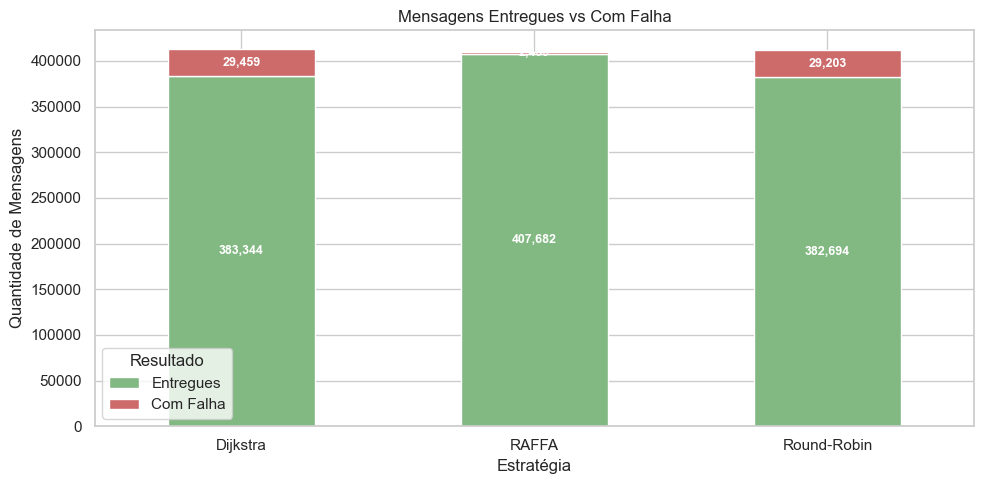

In [128]:
# Delivery rate: successful / (successful + failed)
reliability_records = []
for strat in strategies:
    n_success = len(dfs[strat]) if strat in dfs else 0
    n_fail = len(dfs_failure.get(strat, pd.DataFrame()))
    total = n_success + n_fail
    rate = (n_success / total * 100) if total > 0 else 0
    reliability_records.append({
        T("strategy"): S(strat),
        T("col_successful"): n_success,
        T("col_failed"): n_fail,
        T("col_total_generated"): total,
        T("col_delivery_rate"): round(rate, 2),
    })

df_reliability = pd.DataFrame(reliability_records).set_index(T("strategy"))
display(df_reliability)

# 15a – Delivery rate
plt.figure(figsize=(10, 5))
bars = plt.bar(df_reliability.index, df_reliability[T("col_delivery_rate")],
               color=[STRATEGY_PALETTE.get(s, "gray") for s in df_reliability.index])
plt.title(T("title_delivery_rate"))
plt.ylabel(T("ylabel_delivery_rate"))
plt.ylim(0, 105)
for bar, val in zip(bars, df_reliability[T("col_delivery_rate")]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.xlabel(T("strategy"))
plt.tight_layout()
plt.show()

# 15b – Success vs Failure stacked
fig, ax = plt.subplots(figsize=(10, 5))
df_reliability[[T("col_successful"), T("col_failed")]].plot(
    kind="bar", stacked=True, color=["#82B882", "#CD6B6B"], ax=ax
)
# Annotate each segment with its value
for i, strat in enumerate(df_reliability.index):
    n_success = df_reliability.loc[strat, T("col_successful")]
    n_fail = df_reliability.loc[strat, T("col_failed")]
    # Success label (centered in the green segment)
    ax.text(i, n_success / 2, f"{n_success:,}",
            ha="center", va="center", fontweight="bold", fontsize=9, color="white")
    # Failure label (centered in the red segment)
    if n_fail > 0:
        ax.text(i, n_success + n_fail / 2, f"{n_fail:,}",
                ha="center", va="center", fontweight="bold", fontsize=9, color="white")
ax.set_title(T("title_success_fail"))
ax.set_ylabel(T("message_count"))
ax.set_xlabel(T("strategy"))
ax.legend(title=T("outcome"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Vazão ao Longo do Tempo
*Throughput Over Time*

Mensagens processadas com sucesso por janela de tempo. Revela como cada estratégia mantém a vazão, especialmente durante períodos de falha de nós.

*Messages successfully processed per time window. This reveals how each strategy sustains throughput, especially during node failure periods.*

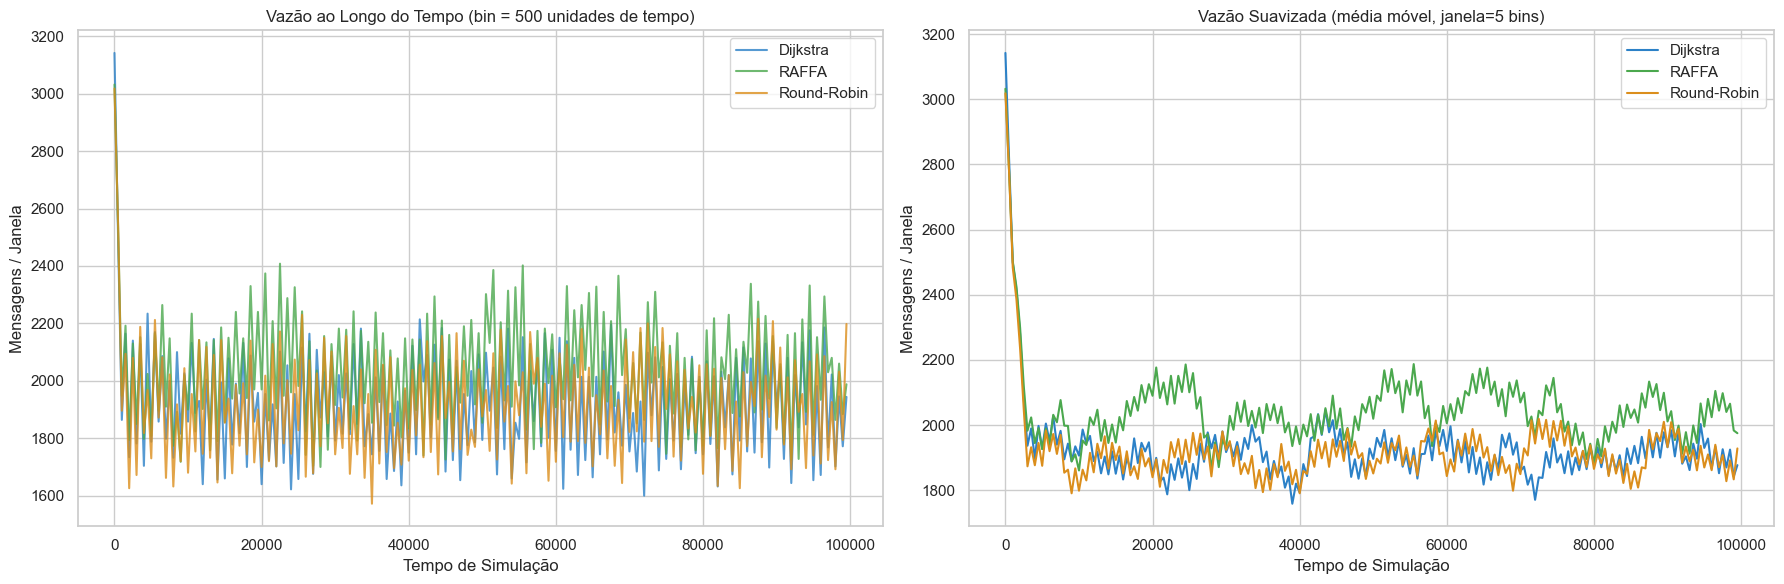

In [129]:
# Throughput: messages completed per time window
BIN_SIZE = 500  # simulation time units

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for strat in strategies:
    if strat in dfs:
        d = dfs[strat].copy()
        d["time_bin"] = (d["time_reception"] // BIN_SIZE) * BIN_SIZE
        throughput = d.groupby("time_bin").size().reset_index(name="msgs")

        axes[0].plot(throughput["time_bin"], throughput["msgs"],
                     label=S(strat), color=STRATEGY_PALETTE[S(strat)], alpha=0.8)

        # Rolling smoothed throughput
        throughput["smooth"] = throughput["msgs"].rolling(window=5, min_periods=1).mean()
        axes[1].plot(throughput["time_bin"], throughput["smooth"],
                     label=S(strat), color=STRATEGY_PALETTE[S(strat)], linewidth=1.5)

axes[0].set_title(T("title_throughput", bin=BIN_SIZE))
axes[0].set_xlabel(T("simulation_time"))
axes[0].set_ylabel(T("ylabel_msgs_window"))
axes[0].legend()

axes[1].set_title(T("title_smooth_throughput"))
axes[1].set_xlabel(T("simulation_time"))
axes[1].set_ylabel(T("ylabel_msgs_window"))
axes[1].legend()

plt.tight_layout()
plt.show()

## 17. Razão de Offload para o Cloud
*Cloud Offload Ratio*

Qual fração das mensagens M_Req é processada pelo nó **Cloud** vs nós **Fog**? Estratégias que enviam mais para o cloud incorrem em maior latência e custo.

*What fraction of M_Req messages are processed by the Cloud node vs Fog nodes? Strategies that offload more to the cloud incur higher latency and cost.*

,Cloud,Fog,Other,Total M_Req,Cloud %,Fog %
Estratégia,,,,,,
Dijkstra,0,191672,0,191672,0.0,100.0
RAFFA,0,203841,0,203841,0.0,100.0
Round-Robin,0,191347,0,191347,0.0,100.0


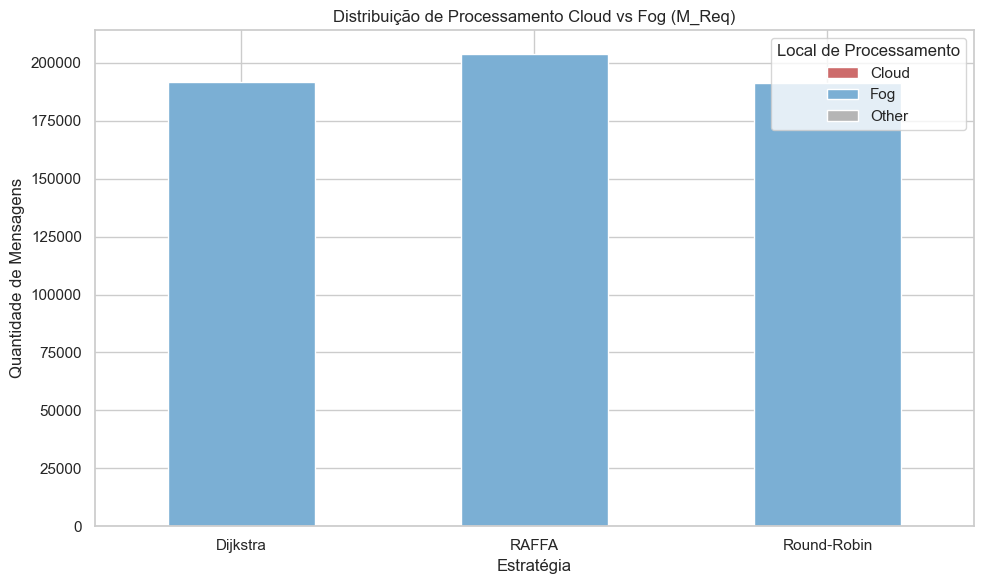

In [130]:
# Cloud vs Fog processing ratio (M_Req only)
offload_records = []
for strat in strategies:
    if strat in dfs:
        d = dfs[strat][dfs[strat]["message"] == "M_Req"]
        total = len(d)
        if total == 0:
            continue
        n_cloud = d["TOPO.dstLabel"].str.lower().str.contains("cloud").sum()
        n_fog = d["TOPO.dstLabel"].str.lower().str.contains("fog").sum()
        n_other = total - n_cloud - n_fog
        offload_records.append({
            T("strategy"): S(strat),
            "Cloud": n_cloud,
            "Fog": n_fog,
            "Other": n_other,
            "Total M_Req": total,
            "Cloud %": round(n_cloud / total * 100, 2),
            "Fog %": round(n_fog / total * 100, 2),
        })

df_offload = pd.DataFrame(offload_records).set_index(T("strategy"))
display(df_offload)

# Stacked bar: Cloud vs Fog
df_offload[["Cloud", "Fog", "Other"]].plot(
    kind="bar", stacked=True, color=["#CD6B6B", "#7BAFD4", "#B5B5B5"], figsize=(10, 6)
)
plt.title(T("title_cloud_fog"))
plt.ylabel(T("message_count"))
plt.xlabel(T("strategy"))
plt.xticks(rotation=0)
plt.legend(title=T("processing_location"))
plt.tight_layout()
plt.show()

## 18. Balanceamento de Carga – Coeficiente de Gini
*Load Balance – Gini Coefficient*

O **coeficiente de Gini** (0 = perfeitamente balanceado, 1 = todo trabalho em um único nó) mede quão uniformemente cada estratégia distribui o processamento entre os nós.

*The Gini coefficient (0 = perfectly balanced, 1 = all work on one node) measures how evenly each strategy distributes processing across nodes.*

,Gini (Service Time),Gini (Message Count),Active Nodes,Max Node Load,Min Node Load
Estratégia,,,,,
Dijkstra,0.1331,0.1349,12,27423,13139
RAFFA,0.1159,0.2290,12,33372,10815
Round-Robin,0.1901,0.0582,12,17725,10979


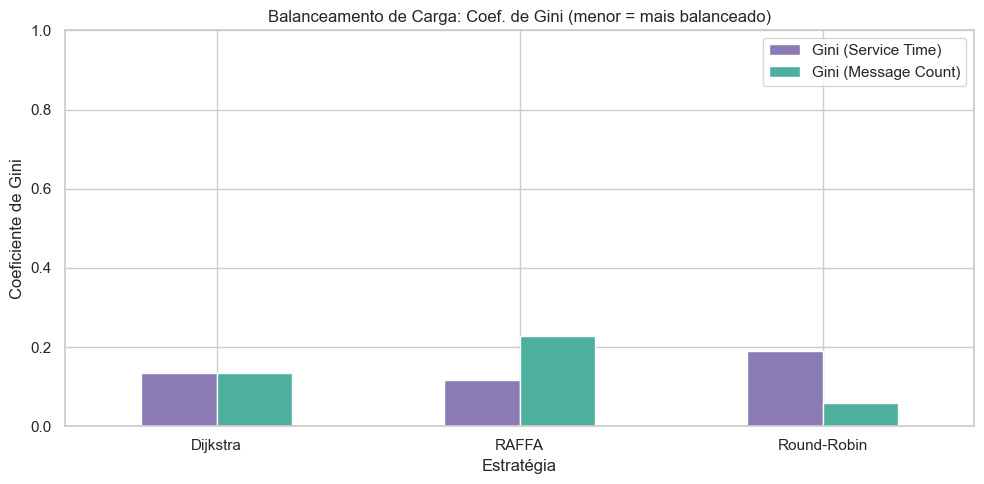

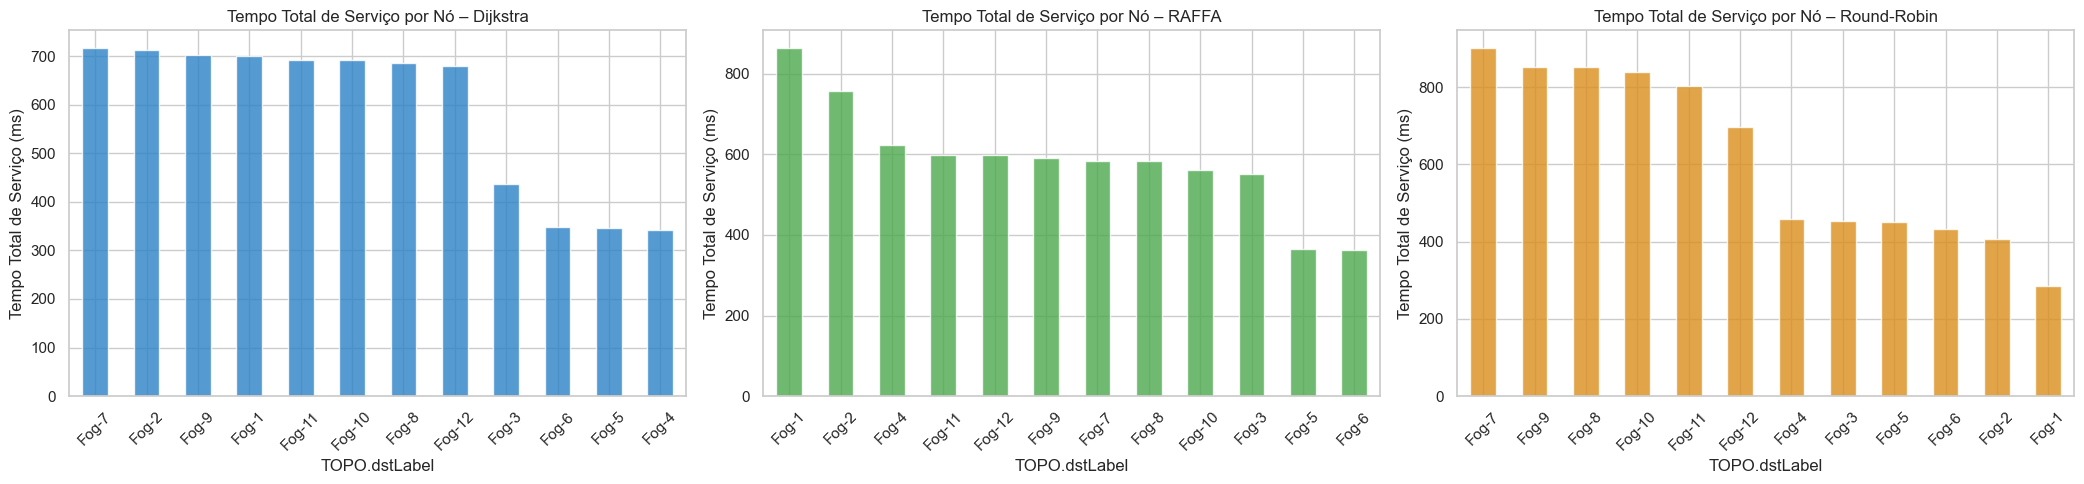

In [131]:
def gini_coefficient(values):
    """Compute Gini coefficient for an array of values."""
    values = np.sort(np.array(values, dtype=float))
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))

# Compute Gini on service time per destination node (M_Req only)
gini_records = []
for strat in strategies:
    if strat in dfs:
        d = dfs[strat][dfs[strat]["message"] == "M_Req"]
        node_service = d.groupby("TOPO.dstLabel")["Service_Time"].sum()
        node_count = d.groupby("TOPO.dstLabel").size()
        gini_records.append({
            T("strategy"): S(strat),
            "Gini (Service Time)": round(gini_coefficient(node_service.values), 4),
            "Gini (Message Count)": round(gini_coefficient(node_count.values), 4),
            "Active Nodes": len(node_count),
            "Max Node Load": node_count.max() if len(node_count) > 0 else 0,
            "Min Node Load": node_count.min() if len(node_count) > 0 else 0,
        })

df_gini = pd.DataFrame(gini_records).set_index(T("strategy"))
display(df_gini)

# Bar chart of Gini coefficients
df_gini[["Gini (Service Time)", "Gini (Message Count)"]].plot(
    kind="bar", color=["#8B7BB5", "#4DAF9E"], figsize=(10, 5)
)
plt.title(T("title_gini"))
plt.ylabel(T("ylabel_gini"))
plt.xlabel(T("strategy"))
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Per-node service time distribution (shows imbalance visually)
active_strats = [s for s in strategies if s in dfs]
fig, axes = plt.subplots(1, len(active_strats),
                         figsize=(7 * len(active_strats), 5))
if not hasattr(axes, '__iter__'):
    axes = [axes]
for ax, strat in zip(axes, active_strats):
    d = dfs[strat][dfs[strat]["message"] == "M_Req"]
    node_svc = d.groupby("TOPO.dstLabel")["Service_Time"].sum().sort_values(ascending=False)
    if node_svc.empty:
        ax.text(0.5, 0.5, T("no_data"), ha="center", va="center", fontsize=14, transform=ax.transAxes)
        ax.set_title(T("title_svc_per_node", strat=S(strat)))
    else:
        node_svc.plot(kind="bar", ax=ax, color=STRATEGY_PALETTE[S(strat)], alpha=0.8)
        ax.set_title(T("title_svc_per_node", strat=S(strat)))
        ax.set_ylabel(T("ylabel_total_svc"))
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 19. Estimativa de Energia
*Energy Estimation*

Estima a energia consumida por estratégia usando os valores de **WATT** da topologia e o tempo de serviço por nó:

$$E_{\text{nó}} = \sum \text{Tempo\_Serviço}_{\text{nó}} \times \text{WATT}_{\text{nó}}$$

| Tipo de Nó | WATT |
|------------|------|
| Cloud | 100.0 |
| Proxy | 40.0 |
| Fog | ~21.0 |
| Dispositivo Final | 0.5 |

*Estimate energy consumed per strategy using WATT values from the topology and per-node service time.*

Valores de WATT por tipo de nó (amostra):
  Cloud: 100.00 W
  End-1: 0.50 W
  End-10: 0.50 W
  End-11: 0.50 W
  End-12: 0.50 W
  End-13: 0.50 W
  End-14: 0.50 W
  End-15: 0.50 W


,Total Energy (J),Energy/Message (J),Energy Cloud (J),Energy Fog (J),Energy Proxy (J),Energy EndDevice (J)
Estratégia,,,,,,
Dijkstra,229551.9718,0.598815,0,229551.9718,0,0.0
RAFFA,225190.3846,0.552368,0,225190.3846,0,0.0
Round-Robin,248561.7935,0.649505,0,248561.7935,0,0.0


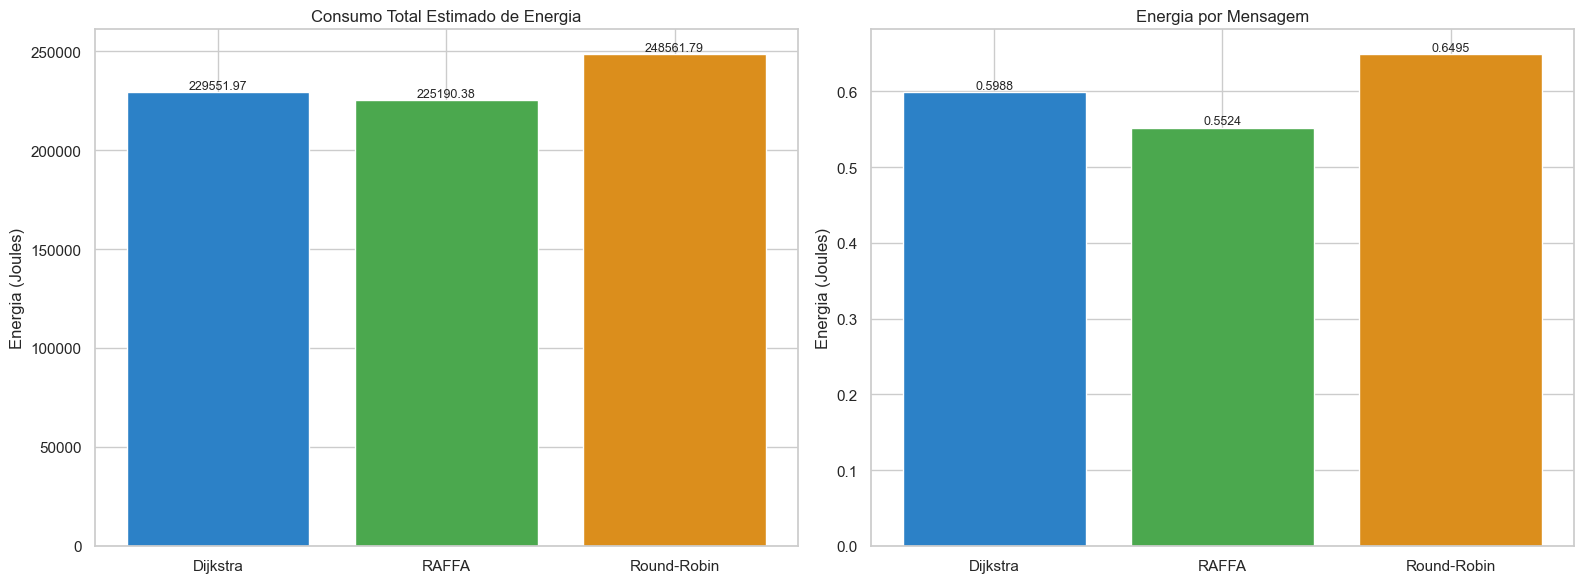

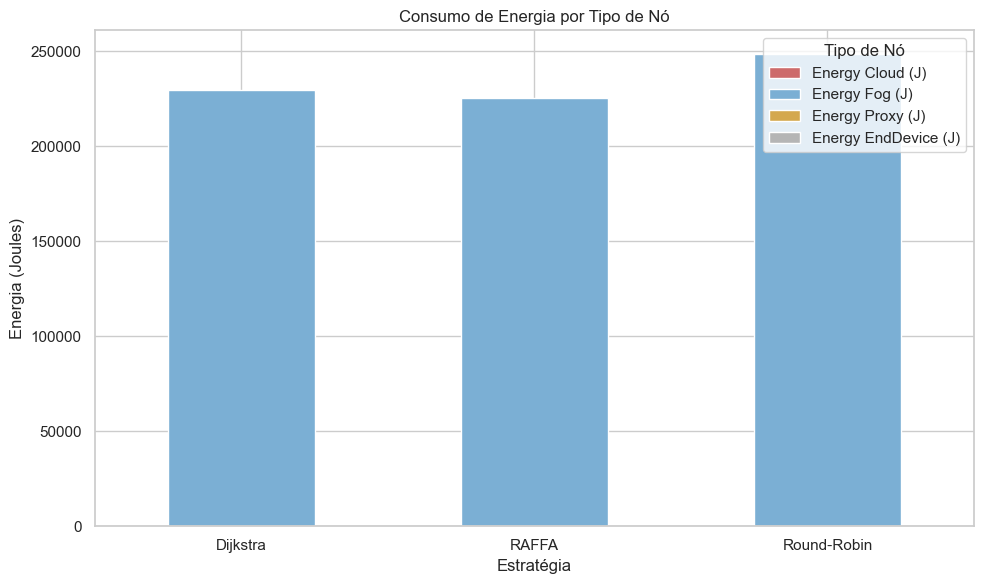

In [132]:
# Load topology to get per-node WATT values
import networkx as nx

topo_path = Path(f"topologies/cloud1-fog12-end48.gexf")
G = nx.read_gexf(str(topo_path))

# Build label -> WATT mapping
label_watt = {}
for node_id, attrs in G.nodes(data=True):
    label = attrs.get("label", node_id)
    watt = float(attrs.get("WATT", 0))
    label_watt[label] = watt

print(T("print_watt_sample"))
for label in sorted(label_watt.keys())[:8]:
    print(f"  {label}: {label_watt[label]:.2f} W")

# Compute energy per strategy
energy_records = []
for strat in strategies:
    if strat not in dfs:
        continue
    d = dfs[strat].copy()
    d["WATT"] = d["TOPO.dstLabel"].map(label_watt).fillna(0)
    d["energy_J"] = d["Service_Time"] * d["WATT"]

    total_energy = d["energy_J"].sum()
    n_msgs = len(d)

    # Per-node-type breakdown
    d["node_type"] = d["TOPO.dstLabel"].str.extract(r"(Cloud|Fog|Proxy|EndDevice|Gateway)", expand=False).fillna("Other")
    type_energy = d.groupby("node_type")["energy_J"].sum()

    rec = {
        T("strategy"): S(strat),
        "Total Energy (J)": round(total_energy, 4),
        "Energy/Message (J)": round(total_energy / n_msgs, 6) if n_msgs > 0 else 0,
    }
    for nt in ["Cloud", "Fog", "Proxy", "EndDevice"]:
        rec[f"Energy {nt} (J)"] = round(type_energy.get(nt, 0), 4)
    energy_records.append(rec)

df_energy = pd.DataFrame(energy_records).set_index(T("strategy"))
display(df_energy)

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total energy
bars = axes[0].bar(df_energy.index, df_energy["Total Energy (J)"],
                   color=[STRATEGY_PALETTE.get(s, "gray") for s in df_energy.index])
axes[0].set_title(T("title_total_energy"))
axes[0].set_ylabel(T("ylabel_energy_j"))
for bar, val in zip(bars, df_energy["Total Energy (J)"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Energy per message
bars2 = axes[1].bar(df_energy.index, df_energy["Energy/Message (J)"],
                    color=[STRATEGY_PALETTE.get(s, "gray") for s in df_energy.index])
axes[1].set_title(T("title_energy_per_msg"))
axes[1].set_ylabel(T("ylabel_energy_j"))
for bar, val in zip(bars2, df_energy["Energy/Message (J)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Energy breakdown by node type
energy_cols = [c for c in df_energy.columns if c.startswith("Energy") and "(J)" in c and "Message" not in c and "Total" not in c]
if energy_cols:
    df_energy[energy_cols].plot(kind="bar", stacked=True, figsize=(10, 6),
                                color=["#CD6B6B", "#7BAFD4", "#D4A84E", "#B5B5B5"][:len(energy_cols)])
    plt.title(T("title_energy_by_type"))
    plt.ylabel(T("ylabel_energy_j"))
    plt.xlabel(T("strategy"))
    plt.xticks(rotation=0)
    plt.legend(title=T("node_type_label"))
    plt.tight_layout()
    plt.show()

## 20. Mensagens Não Processadas (Fila ao Final da Simulação)
*Unprocessed Messages (End-of-Simulation Queue)*

Mensagens que ainda estavam em trânsito ou na fila quando a simulação terminou. Mais mensagens não processadas = mais congestionamento/gargalo.

*Messages still in transit or queued when the simulation ended. More unprocessed messages = more congestion/bottleneck.*

In [133]:
import os

unprocessed_path = Path("results/unprocessed_messages.csv")

if unprocessed_path.exists():
    df_unproc = pd.read_csv(unprocessed_path)
    print(f"{T('print_total_unproc')}: {len(df_unproc):,}")
    display(df_unproc.head())

    if len(df_unproc) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # By queue type
        sns.countplot(x="QueueType", data=df_unproc, ax=axes[0], palette="Set2")
        axes[0].set_title(T("title_unproc_queue"))
        axes[0].tick_params(axis="x", rotation=30)

        # By application (top 15)
        top_apps = df_unproc["App"].value_counts().nlargest(15).index
        df_unproc_top = df_unproc[df_unproc["App"].isin(top_apps)]
        sns.countplot(x="App", data=df_unproc_top, order=top_apps, ax=axes[1], palette="Set2")
        axes[1].set_title(T("title_unproc_app"))
        axes[1].tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()

        # Distribution of projected completion time
        df_unproc["Until"] = pd.to_numeric(df_unproc["Until"], errors="coerce")
        if df_unproc["Until"].notna().any():
            plt.figure(figsize=(10, 5))
            sns.histplot(df_unproc["Until"].dropna(), kde=True, color="red", bins=30)
            plt.title(T("title_unproc_completion"))
            plt.xlabel(T("simulation_time"))
            plt.tight_layout()
            plt.show()
    else:
        print(f"✅ {T('no_unproc')}")
else:
    print(T("unproc_not_found"))

Total de mensagens não processadas: 0


,QueueType,App,Message,Src,Dst,Timestamp,Path,CurrentNode,Until


✅ Sem mensagens não processadas — todas concluídas!


## 21. Tabela Resumo Estendida
*Extended Summary Table*

Uma tabela abrangente de KPIs reunindo **todas** as métricas entre estratégias para fácil comparação.

*A comprehensive KPI table collecting all metrics across strategies for easy comparison.*

In [134]:
# Build extended summary joining all computed metrics
ext_records = []
for strat in strategies:
    if strat not in dfs:
        continue
    d = dfs[strat]
    n_success = len(d)
    n_fail = len(dfs_failure.get(strat, pd.DataFrame()))
    total_gen = n_success + n_fail

    rec = {
        T("strategy"): S(strat),
        # --- Latency ---
        T("col_mean_lat"): d["Latency"].mean(),
        T("col_median_lat"): d["Latency"].median(),
        T("col_p95_lat"): d["Latency"].quantile(0.95),
        T("col_p99_lat"): d["Latency"].quantile(0.99),
        T("col_std_lat"): d["Latency"].std(),
        # --- Decomposition ---
        T("col_network"): d["time_network"].mean() if "time_network" in d.columns else np.nan,
        T("col_queue_wait"): d["time_queue"].mean() if "time_queue" in d.columns else np.nan,
        T("col_processing"): d["Service_Time"].mean(),
        # --- Reliability ---
        T("col_successful"): n_success,
        T("col_failed"): n_fail,
        T("col_delivery_rate"): (n_success / total_gen * 100) if total_gen > 0 else 0,
    }

    # --- Cloud offload ---
    d_req = d[d["message"] == "M_Req"]
    if len(d_req) > 0:
        n_cloud = d_req["TOPO.dstLabel"].str.lower().str.contains("cloud").sum()
        rec["Cloud Offload (%)"] = n_cloud / len(d_req) * 100
    else:
        rec["Cloud Offload (%)"] = np.nan

    # --- Load balance ---
    if len(d_req) > 0:
        node_count = d_req.groupby("TOPO.dstLabel").size()
        rec["Gini (Msg Count)"] = gini_coefficient(node_count.values)
    else:
        rec["Gini (Msg Count)"] = np.nan

    # --- Energy ---
    if S(strat) in df_energy.index:
        rec["Total Energy (J)"] = df_energy.loc[S(strat), "Total Energy (J)"]
        rec["Energy/Msg (J)"] = df_energy.loc[S(strat), "Energy/Message (J)"]

    # --- Network ---
    if strat in dfs_link:
        dl = dfs_link[strat]
        rec["Total Bytes Tx"] = dl["size"].sum()
        rec["Avg Hops/Msg"] = dl.groupby("id").size().mean()
        rec["Avg Link Wait"] = dl["wait"].mean()
        rec["Peak Buffer"] = dl["buffer"].max()

    ext_records.append(rec)

df_extended = pd.DataFrame(ext_records).set_index(T("strategy")).round(4)

# Display transposed for readability (metrics as rows, strategies as columns)
display(df_extended.T.fillna("—"))

Estratégia,Dijkstra,RAFFA,Round-Robin
Latência Média (ms),8.361600e+00,1.002820e+01,1.357560e+01
Latência Mediana (ms),8.030700e+00,8.051400e+00,1.206770e+01
Latência P95 (ms),1.397310e+01,2.396840e+01,2.401670e+01
Latência P99 (ms),1.797460e+01,3.602920e+01,2.802420e+01
Desvio Padrão (ms),3.003200e+00,6.369100e+00,4.860900e+00
Rede (ms),8.343200e+00,1.001090e+01,1.355610e+01
Espera na Fila (ms),0.000000e+00,0.000000e+00,0.000000e+00
Processamento (ms),1.840000e-02,1.730000e-02,1.940000e-02
Entregues,3.833440e+05,4.076820e+05,3.826940e+05
Com Falha,2.945900e+04,2.439000e+03,2.920300e+04


## 22. Conclusão Final
*Final Conclusion*

A tabela resumo estendida (Seção 21) fornece uma comparação em visão única em todas as dimensões-chave:

| Dimensão | Métrica Principal | Melhor Estratégia = |
|----------|------------------|---------------------|
| **Latência** | Média / P95 / P99 | Menores valores |
| **Confiabilidade** | Taxa de Entrega (%) | Maior valor |
| **Energia** | Energia/Mensagem (J) | Menor valor |
| **Balanceamento de Carga** | Coeficiente de Gini | Mais próximo de 0 |
| **Dependência do Cloud** | Offload para Cloud (%) | Depende do objetivo |
| **Eficiência de Rede** | Média de Saltos, Buffer de Pico | Menor = melhor |
| **Vazão** | Mensagens sustentadas/janela | Maior = melhor |

Utilize estes resultados para justificar qual estratégia é mais apropriada para o cenário de computação em névoa sob avaliação.

*Use these results to justify which strategy is most appropriate for the fog computing scenario under evaluation.*